# Desarrollo de Entrega Unidad 4 – Base de Datos de tienda usando las Unidades 9 y 10

En este caso trabajaremos con una base de datos de órdenes de bases de datos de tienda de la unidad 4.

Iniciemos importando las librerías necesarias

In [111]:
#!conda install sklearn.ensemble -y
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm
from sklearn.ensemble import IsolationForest
import plotly.express as px
import plotly.graph_objects as go

# Cargando y Analizando la Base de datos
Ahora importamos nuestra base de datos

In [112]:
consumer_data = pd.read_excel('data/Online Retail.xlsx')
consumer_data

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


# Cambiar los nombres de la base de datos creando un directorio 

In [113]:
from os import rename
consumer_data.rename(columns={'InvoiceNo':'Numero_factura','StockCode':'Cod_prod','Description':'Nombre_Producto','Quantity':'Cantidad','UnitPrice':'Precio unitario','InvoiceDate':'Fecha_compra','CustomerID':'Cod_Cliente','Country':'País'},inplace=True)
#consumer_data = pd.DataFrame(consumer_dat["Numero_factura"].astype(str))
#consumer_data.to_csv('data/Online_Retail.csv')
consumer_data

,Numero_factura,Cod_prod,Nombre_Producto,Cantidad,Fecha_compra,Precio unitario,Cod_Cliente,País
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


Se analiza la estadistica de las variables númericas

In [114]:

consumer_data.describe()

,Cantidad,Fecha_compra,Precio unitario,Cod_Cliente
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


Tipo de datos que se tienen

In [115]:
consumer_data.dtypes

Numero_factura             object
Cod_prod                   object
Nombre_Producto            object
Cantidad                    int64
Fecha_compra       datetime64[us]
Precio unitario           float64
Cod_Cliente               float64
País                          str
dtype: object

In [116]:
print('Cantidad de paises: ', consumer_data['País'].nunique())
print('Cantidad de productos: ', consumer_data['Cod_prod'].nunique())
print('Cantidad de usuarios: ', consumer_data['Cod_Cliente'].nunique())

Cantidad de paises:  38
Cantidad de productos:  4070
Cantidad de usuarios:  4372


C:\Users\adolp\AppData\Local\Temp\ipykernel_35252\1810569295.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=paises_ordenes.values, y=paises_traducidos, palette='viridis',color='goldenrod')


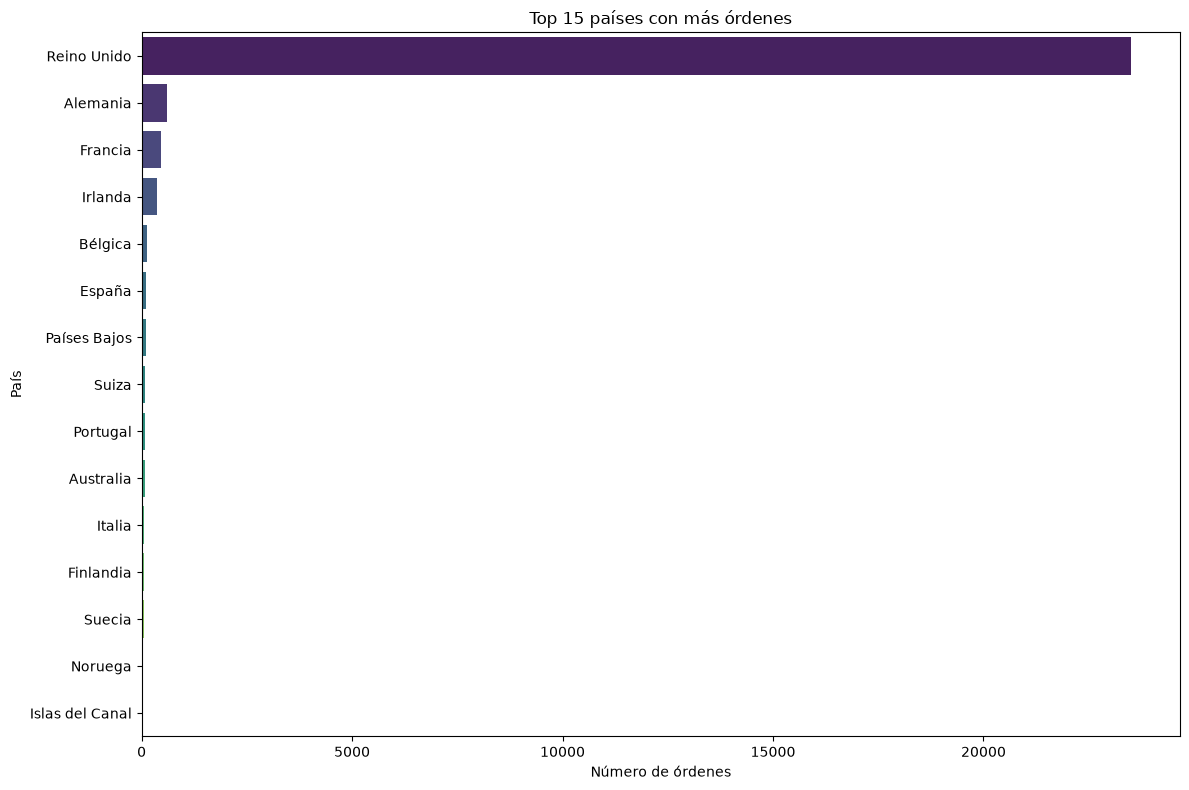

In [117]:
# Gráfica de órdenes por país con nombres en español
paises_ordenes = consumer_data.groupby('País')['Numero_factura'].nunique().sort_values(ascending=False).head(15)

traduccion_paises = {
    'United Kingdom': 'Reino Unido',
    'France': 'Francia',
    'Germany': 'Alemania',
    'Spain': 'España',
    'Poland': 'Polonia',
    'Netherlands': 'Países Bajos',
    'Belgium': 'Bélgica',
    'Switzerland': 'Suiza',
    'Portugal': 'Portugal',
    'Australia': 'Australia',
    'Norway': 'Noruega',
    'EIRE': 'Irlanda',
    'Sweden': 'Suecia',
    'Denmark': 'Dinamarca',
    'Finland': 'Finlandia',
    'Italy': 'Italia',
    'Channel Islands': 'Islas del Canal',
    'Cyprus': 'Chipre',    
}

paises_traducidos = [traduccion_paises.get(p, p) for p in paises_ordenes.index]

plt.figure(figsize=(12, 8))
sns.barplot(x=paises_ordenes.values, y=paises_traducidos, palette='viridis',color='goldenrod')
plt.title('Top 15 países con más órdenes')
plt.xlabel('Número de órdenes')
plt.ylabel('País')
plt.tight_layout()
plt.show()

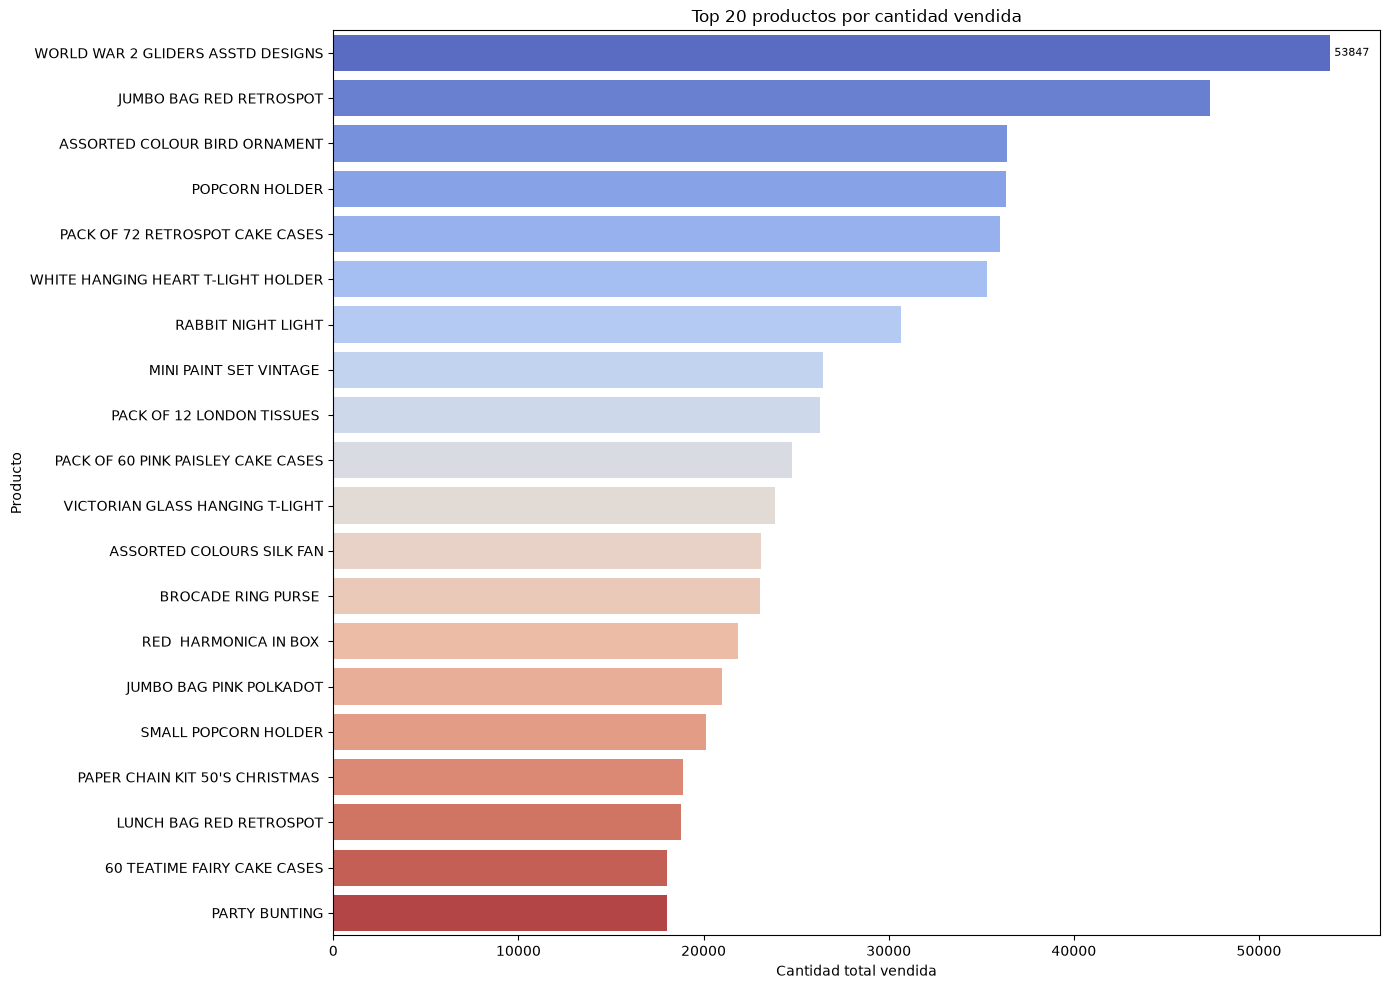

In [118]:
codigos_especiales = ['POST', 'DOT', 'M', 'BANK CHARGES', 'AMAZONFEE', 'CRUK', 'PADS', 'C2']

productos_mas_vendidos = (
    consumer_data[~consumer_data['Cod_prod'].isin(codigos_especiales)]
    .groupby('Nombre_Producto')['Cantidad']
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(14, 10))
sns.barplot(x=productos_mas_vendidos.values, y=productos_mas_vendidos.index,
            hue=productos_mas_vendidos.index, palette='coolwarm', legend=False, ax=ax)
ax.bar_label(ax.containers[0], fmt='%.0f', padding=3, fontsize=8)
ax.set_title('Top 20 productos por cantidad vendida')
ax.set_xlabel('Cantidad total vendida')
ax.set_ylabel('Producto')
plt.tight_layout()
plt.show()

Verifiquemos si tenemos valores faltantes en nuestra base de datos

In [119]:
consumer_data.isna().sum()

Numero_factura          0
Cod_prod                0
Nombre_Producto      1454
Cantidad                0
Fecha_compra            0
Precio unitario         0
Cod_Cliente        135080
País                    0
dtype: int64

# Tratamiento de la base de Datos
Teniendo en cuenta el código del producto se rellenaran los espacios

In [120]:
def completar_nombres_productos(df):
    """
    Rellena los espacios en blanco (valores nulos) de la columna 'Nombre_Producto' 
    buscando el nombre asociado a su 'Cod_prod' en el resto del DataFrame.
    """
    # 1. Creamos un mapeo (diccionario) de Cod_prod -> Nombre_Producto
    # Descartamos los nulos y nos quedamos con la primera aparición de cada producto
    mapeo_nombres = (
        df[['Cod_prod', 'Nombre_Producto']]
        .dropna(subset=['Nombre_Producto'])
        .drop_duplicates(subset=['Cod_prod'])
        .set_index('Cod_prod')['Nombre_Producto']
    )
    
    # 2. Rellenamos los valores nulos en 'Nombre_Producto' usando la función map() 
    # que busca el Cod_prod en nuestro mapeo
    df['Nombre_Producto'] = df['Nombre_Producto'].fillna(df['Cod_prod'].map(mapeo_nombres))
    
    return df

# funcion adicional 


# Ejemplo de uso con tu DataFrame:
consumer_data = completar_nombres_productos(consumer_data)

# Para verificar que funcionó (opcional):
print("Valores nulos en 'Nombre_Producto':", consumer_data['Nombre_Producto'].isnull().sum())


Valores nulos en 'Nombre_Producto': 112


Verificamos el resultado

In [121]:
consumer_data.isna().sum()

Numero_factura          0
Cod_prod                0
Nombre_Producto       112
Cantidad                0
Fecha_compra            0
Precio unitario         0
Cod_Cliente        135080
País                    0
dtype: int64

In [122]:
consumer_data

,Numero_factura,Cod_prod,Nombre_Producto,Cantidad,Fecha_compra,Precio unitario,Cod_Cliente,País
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


# Tener pendiente consumer_data_a para el analisis de algoritmos no descriptivos

In [123]:

# Reemplazar celdas vacías en Cod_Cliente por NaN
consumer_data_a = consumer_data.copy()
consumer_data_a['Cod_Cliente'] = consumer_data_a['Cod_Cliente'].replace(['', ' ', np.nan], np.nan)

# Mostrar el conteo de valores NaN después del reemplazo
print("Valores NaN después del reemplazo:")
print(consumer_data_a.isna().sum())
#print("\nValores únicos en Cod_Cliente (primeros 10):")
#print(consumer_data_a['Cod_Cliente'].unique()[:10])

Valores NaN después del reemplazo:
Numero_factura          0
Cod_prod                0
Nombre_Producto       112
Cantidad                0
Fecha_compra            0
Precio unitario         0
Cod_Cliente        135080
País                    0
dtype: int64


In [124]:
# Reemplazar valores vacíos en Cod_Cliente por NaN y eliminar filas de consumer_data
consumer_data['Cod_Cliente'] = consumer_data['Cod_Cliente'].replace(['', ' '], np.nan)

filas_antes = len(consumer_data)
filas_vacias = consumer_data['Cod_Cliente'].isna().sum()
print(f"Número de filas antes de eliminar: {filas_antes}")
print(f"Filas con Cod_Cliente vacío: {filas_vacias}")

# Eliminar filas con Cod_Cliente vacío en consumer_data
consumer_data = consumer_data.dropna(subset=['Cod_Cliente']).reset_index(drop=True)
filas_despues = len(consumer_data)
print(f"\nNúmero de filas después de eliminar: {filas_despues}")
print(f"Filas eliminadas: {filas_antes - filas_despues}")
print(f"Filas vacías restantes en Cod_Cliente: {consumer_data['Cod_Cliente'].isna().sum()}")

Número de filas antes de eliminar: 541909
Filas con Cod_Cliente vacío: 135080

Número de filas después de eliminar: 406829
Filas eliminadas: 135080
Filas vacías restantes en Cod_Cliente: 0


# Eliminar los datos duplicados 

In [125]:
print(f"consumer_data — filas antes: {len(consumer_data)}")
print(f"Duplicados exactos encontrados: {consumer_data.duplicated().sum()}")
consumer_data = consumer_data.drop_duplicates().reset_index(drop=True)
print(f"consumer_data — filas después: {len(consumer_data)}")

print(f"\nconsumer_data_a — filas antes: {len(consumer_data_a)}")
print(f"Duplicados exactos encontrados: {consumer_data_a.duplicated().sum()}")
consumer_data_a = consumer_data_a.drop_duplicates().reset_index(drop=True)
print(f"consumer_data_a — filas después: {len(consumer_data_a)}")

consumer_data — filas antes: 406829
Duplicados exactos encontrados: 5225
consumer_data — filas después: 401604

consumer_data_a — filas antes: 541909
Duplicados exactos encontrados: 5268
consumer_data_a — filas después: 536641


# Anexando una columna de estado de la compraer eincluye la columna monto para luego hacer analisisq

In [126]:
consumer_data['Monto'] = consumer_data['Cantidad'] * consumer_data['Precio unitario']
consumer_data_a['Monto'] = consumer_data_a['Cantidad'] * consumer_data_a['Precio unitario']

consumer_data[['Cantidad', 'Precio unitario', 'Monto']].describe()

,Cantidad,Precio unitario,Monto
count,401604.000000,401604.000000,401604.000000
mean,12.183273,3.474064,20.613638
std,250.283037,69.764035,430.352218
min,-80995.000000,0.000000,-168469.600000
25%,2.000000,1.250000,4.250000
50%,5.000000,1.950000,11.700000
75%,12.000000,3.750000,19.800000
max,80995.000000,38970.000000,168469.600000


Anexando una columna de estado de la compra

In [127]:
def asignar_estado_compra(df):
    """
    Crea una nueva columna 'Estado de la compra'.
    Si el 'Numero_factura' contiene la letra 'C', se marca como 'Cancelado', 
    de lo contrario se marca como 'Realizado'.
    """
    # 1. Nos aseguramos de tratar la columna Numero_factura como texto (string)
    # 2. Comprobamos si contiene la letra 'C' (case=False para que no distinga entre mayúsculas y minúsculas)
    condicion_cancelado = df['Numero_factura'].astype(str).str.contains('C', case=False, na=False)
    
    # 3. np.where funciona así: np.where(condicion, valor_si_verdadero, valor_si_falso)
    df['Estado de la compra'] = np.where(condicion_cancelado, 'Cancelado', 'Realizado')
    
    return df
# Ejemplo de uso con tu DataFrame:
consumer_data = asignar_estado_compra(consumer_data)
# Para verificar que funcionó viendo algunas filas canceladas:
display(consumer_data[consumer_data['Estado de la compra'] == 'Cancelado'].head())

,Numero_factura,Cod_prod,Nombre_Producto,Cantidad,Fecha_compra,Precio unitario,Cod_Cliente,País,Monto,Estado de la compra
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom,-27.50,Cancelado
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,-4.65,Cancelado
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,-19.80,Cancelado
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96,Cancelado
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96,Cancelado


Se adiciona la linea para trasformar la columna Numero de Factura a tipo texto.  

In [128]:
consumer_data["Numero_factura"] = consumer_data["Numero_factura"].astype(str)
consumer_data["Cod_prod"] = consumer_data["Cod_prod"].astype(str)
consumer_data["Nombre_Producto"] = consumer_data["Nombre_Producto"].astype(str)
consumer_data["Cod_Cliente"] = consumer_data["Cod_Cliente"].astype(str)
consumer_data


,Numero_factura,Cod_prod,Nombre_Producto,Cantidad,Fecha_compra,Precio unitario,Cod_Cliente,País,Monto,Estado de la compra
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,Realizado
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Realizado
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,Realizado
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Realizado
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Realizado
...,...,...,...,...,...,...,...,...,...,...
401599,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,Realizado
401600,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,Realizado
401601,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,Realizado
401602,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,Realizado


Se realiza una la priemra grafica

se agrega las columnas fecha día mes hora

In [129]:
# 2. Creamos las nuevas columnas extrayendo la información
dias_semana = {
    0: 'Lunes', 1: 'Martes', 2: 'Miércoles',
    3: 'Jueves', 4: 'Viernes', 5: 'Sábado', 6: 'Domingo'
}
#consumer_data['Dia_compra'] = consumer_data['Fecha_compra'].dt.dayofweek.map(dias_semana)

consumer_data['Mes_compra'] = consumer_data['Fecha_compra'].dt.month
meses_mapping = {
    1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril',
    5: 'Mayo', 6: 'Junio', 7: 'Julio', 8: 'Agosto',
    9: 'Septiembre', 10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'
}
consumer_data['Mes_compra'] = consumer_data['Mes_compra'].map(meses_mapping)
consumer_data['Mes_compra'] = pd.Categorical(
    consumer_data['Mes_compra'],
    categories=list(meses_mapping.values()),
    ordered=True
)
consumer_data['Hora_compra'] = consumer_data['Fecha_compra'].dt.hour
# Para verificar que las columnas se crearon correctamente:
display(consumer_data[['Fecha_compra', 'Mes_compra', 'Hora_compra']].head())
consumer_data

,Fecha_compra,Mes_compra,Hora_compra
0,2010-12-01 08:26:00,Diciembre,8
1,2010-12-01 08:26:00,Diciembre,8
2,2010-12-01 08:26:00,Diciembre,8
3,2010-12-01 08:26:00,Diciembre,8
4,2010-12-01 08:26:00,Diciembre,8


,Numero_factura,Cod_prod,Nombre_Producto,Cantidad,Fecha_compra,Precio unitario,Cod_Cliente,País,Monto,Estado de la compra,Mes_compra,Hora_compra
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,Realizado,Diciembre,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Realizado,Diciembre,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,Realizado,Diciembre,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Realizado,Diciembre,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Realizado,Diciembre,8
...,...,...,...,...,...,...,...,...,...,...,...,...
401599,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,Realizado,Diciembre,12
401600,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,Realizado,Diciembre,12
401601,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,Realizado,Diciembre,12
401602,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,Realizado,Diciembre,12


<Axes: xlabel='Mes_compra'>

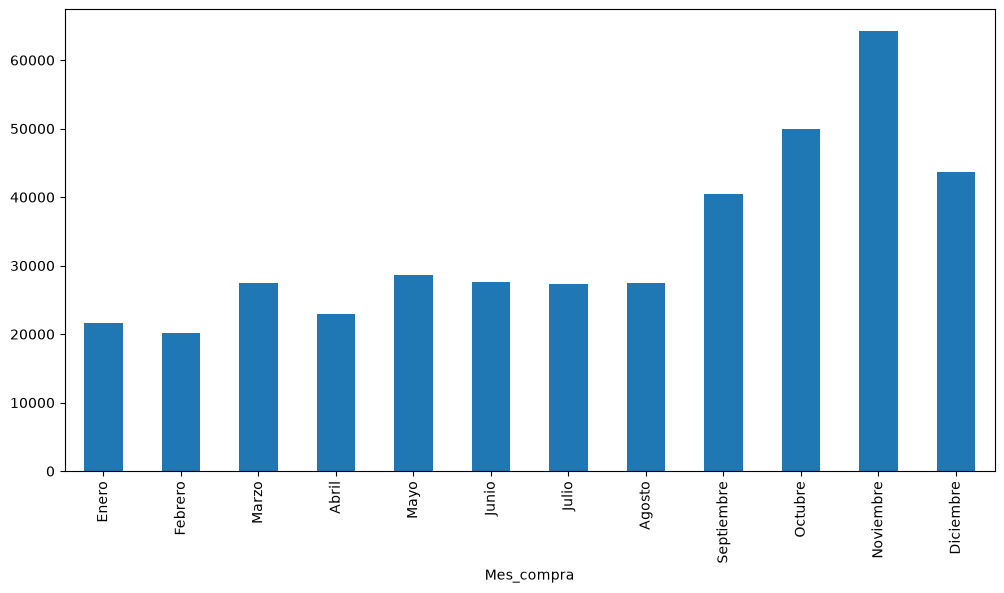

In [130]:
#consumer_data = consumer_data.order(columns={'1': 'Enero', '2': 'Febrero', '3': 'Marzo', '4': 'Abril', '5': 'Mayo', '6': 'Junio', '7': 'Julio', '8': 'Agosto', '9': 'Septiembre', '10': 'Octubre', '11': 'Noviembre', '12': 'Diciembre'})
consumer_data['Mes_compra'].value_counts().sort_index().plot(kind='bar', figsize=(12, 6))


In [131]:
consumer_data.describe()

,Cantidad,Fecha_compra,Precio unitario,Monto,Hora_compra
count,401604.000000,401604,401604.000000,401604.000000,401604.000000
mean,12.183273,2011-07-10 12:08:23.848567,3.474064,20.613638,12.731031
min,-80995.000000,2010-12-01 08:26:00,0.000000,-168469.600000,6.000000
25%,2.000000,2011-04-06 15:02:00,1.250000,4.250000,11.000000
50%,5.000000,2011-07-29 15:40:00,1.950000,11.700000,13.000000
75%,12.000000,2011-10-20 11:58:30,3.750000,19.800000,14.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,168469.600000,20.000000
std,250.283037,NaN,69.764035,430.352218,2.288211


se vuelve a ver que tipo de datos que tiene la base 

In [132]:
consumer_data.dtypes

Numero_factura                    str
Cod_prod                          str
Nombre_Producto                   str
Cantidad                        int64
Fecha_compra           datetime64[us]
Precio unitario               float64
Cod_Cliente                       str
País                              str
Monto                         float64
Estado de la compra               str
Mes_compra                   category
Hora_compra                     int32
dtype: object

In [133]:
#consumer_data['Dia_compra'].order = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
#consumer_data['Dia_compra'].value_counts().reindex(['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sabado', 'Domingo']).plot(kind='bar', figsize=(12, 6))
consumer_data['Dia_semana'] = consumer_data['Fecha_compra'].dt.day_name()

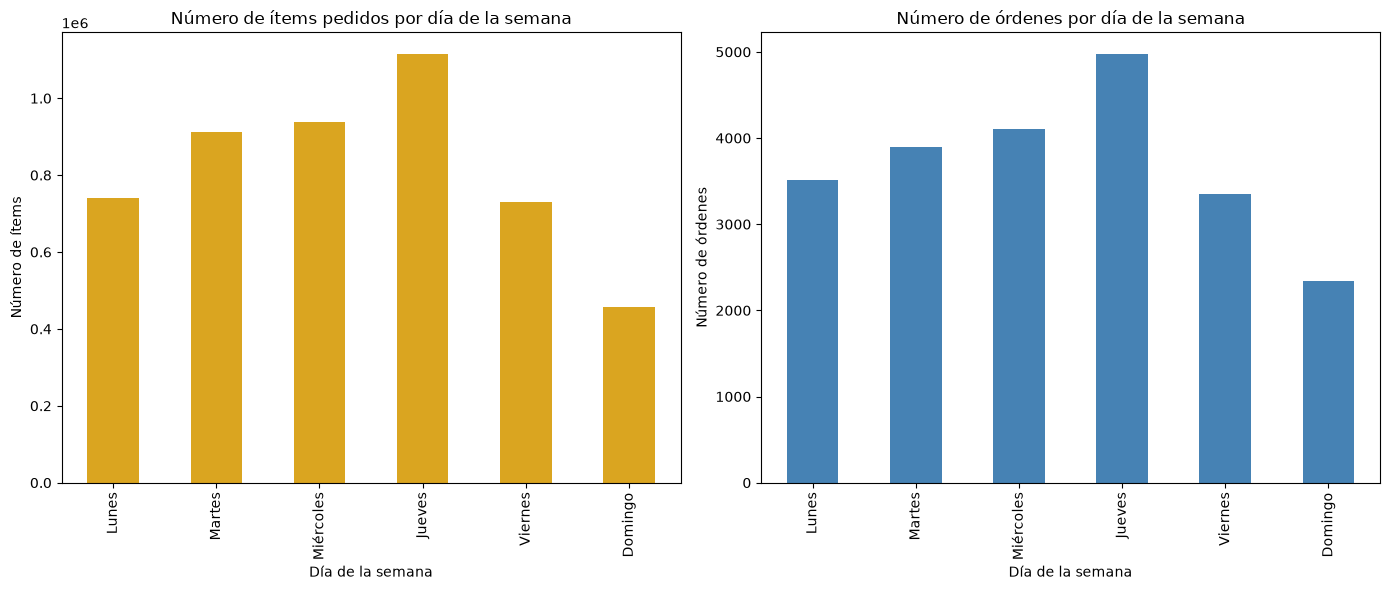

In [134]:
# 1. Crear la columna de día de la semana (en español, ordenada Lunes->Domingo)
dias_es = {0:'Lunes', 1:'Martes', 2:'Miércoles', 3:'Jueves', 4:'Viernes', 5:'Sábado', 6:'Domingo'}
consumer_data['Dia_semana'] = consumer_data['Fecha_compra'].dt.dayofweek.map(dias_es)
orden_dias = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']
consumer_data['Dia_semana'] = pd.Categorical(consumer_data['Dia_semana'], categories=orden_dias, ordered=True)

# 2. Agregaciones correctas por día de la semana
items_por_dia = consumer_data.groupby('Dia_semana')['Cantidad'].sum()
ordenes_por_dia = consumer_data.groupby('Dia_semana')['Numero_factura'].nunique()

# 3. Graficar
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

items_por_dia.plot(kind='bar', ax=axes[0], color='goldenrod')
axes[0].set_title('Número de ítems pedidos por día de la semana')
axes[0].set_xlabel('Día de la semana')
axes[0].set_ylabel('Número de ítems')

ordenes_por_dia.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Número de órdenes por día de la semana')
axes[1].set_xlabel('Día de la semana')
axes[1].set_ylabel('Número de órdenes')

plt.tight_layout()
plt.show()

# Grafico de los paises a los cuales se envia los articulos 

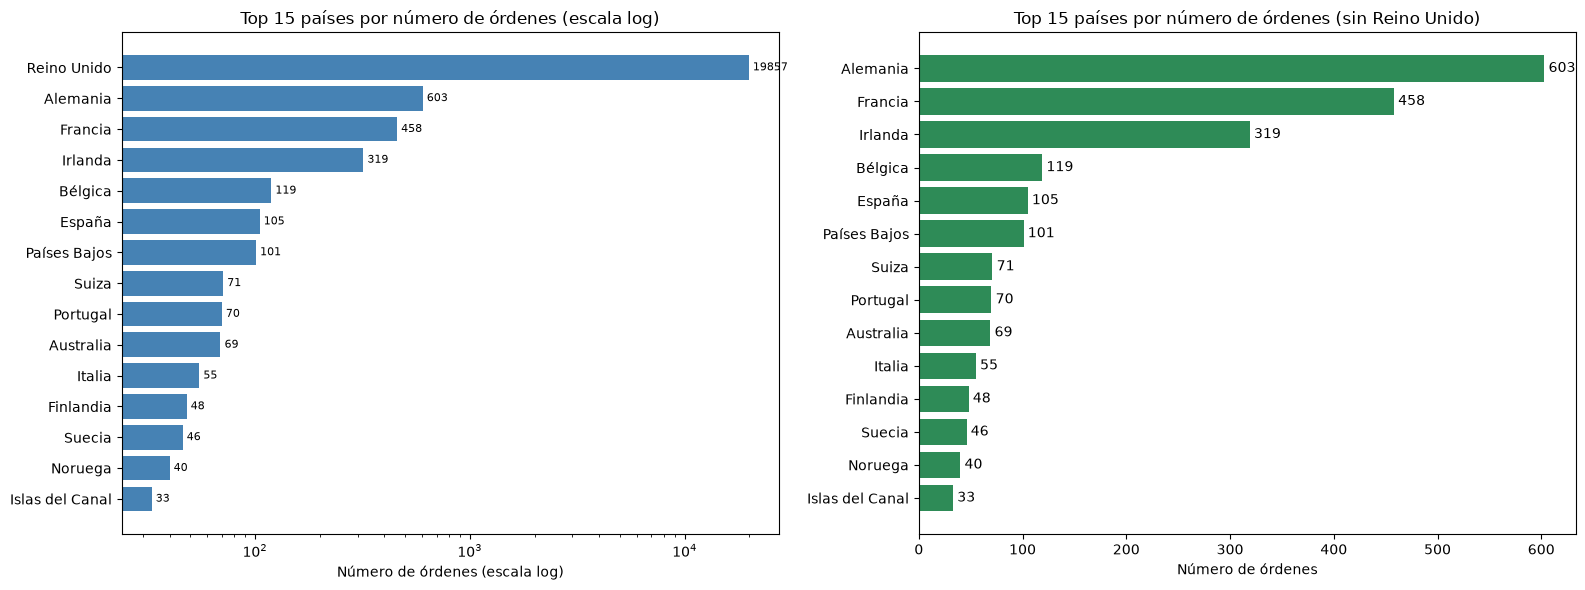

In [135]:

# Métrica correcta: facturas únicas, no filas
traduccion_paises = {
    'United Kingdom': 'Reino Unido',
    'France': 'Francia',
    'Germany': 'Alemania',
    'Spain': 'España',
    'Poland': 'Polonia',
    'Netherlands': 'Países Bajos',
    'Belgium': 'Bélgica',
    'Switzerland': 'Suiza',
    'Portugal': 'Portugal',
    'Australia': 'Australia',
    'Norway': 'Noruega',
    'EIRE': 'Irlanda',
    'Sweden': 'Suecia',
    'Denmark': 'Dinamarca',
    'Finland': 'Finlandia',
    'Italy': 'Italia',
    'Channel Islands': 'Islas del Canal',
    'Cyprus': 'Chipre',    
}

ordenes_por_pais = consumer_data.groupby('País')['Numero_factura'].nunique().sort_values(ascending=False)
top15 = ordenes_por_pais.head(15)
top15.index = [traduccion_paises.get(p, p) for p in top15.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].barh(top15.index[::-1], top15.values[::-1], color='steelblue')
axes[0].bar_label(axes[0].containers[0], fmt='%.0f', padding=3, fontsize=8)
axes[0].set_xscale('log')

# 
# 

axes[0].set_title('Top 15 países por número de órdenes (escala log)')
axes[0].set_xlabel('Número de órdenes (escala log)')

top15_sin_uk = top15.drop('Reino Unido', errors='ignore')
axes[1].barh(top15_sin_uk.index[::-1], top15_sin_uk.values[::-1], color='seagreen')
axes[1].bar_label(axes[1].containers[0], fmt='%.0f', padding=3)
axes[1].set_title('Top 15 países por número de órdenes (sin Reino Unido)')
axes[1].set_xlabel('Número de órdenes')

plt.tight_layout()
plt.show()


Analisis de Hora del día

C:\Users\adolp\AppData\Local\Temp\ipykernel_35252\1801127518.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=compras_por_hora.index, y=compras_por_hora.values, palette='mako')


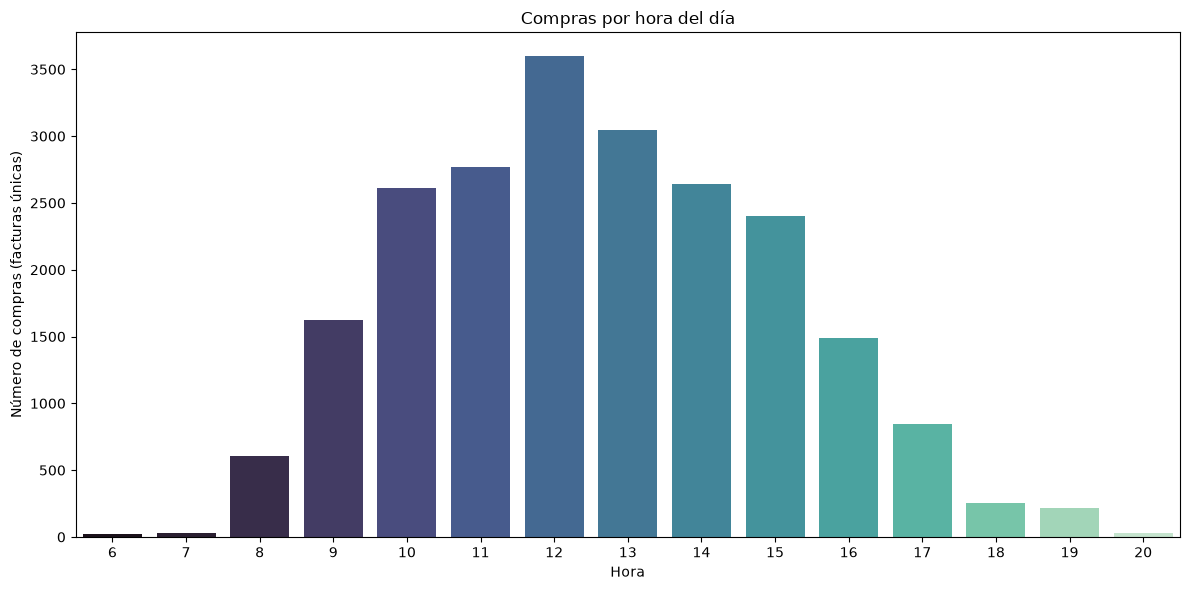

In [136]:
# Gráfico de compras por hora del día
compras_por_hora = consumer_data.groupby('Hora_compra')['Numero_factura'].nunique().sort_index()
plt.figure(figsize=(12, 6))
sns.barplot(x=compras_por_hora.index, y=compras_por_hora.values, palette='mako')
plt.title('Compras por hora del día')
plt.xlabel('Hora')
plt.ylabel('Número de compras (facturas únicas)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Analisis de compras por producto y pais

In [137]:
producto_mas = pd.crosstab(consumer_data['Dia_semana'], consumer_data['Nombre_Producto'])
producto_mas

Nombre_Producto,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
Dia_semana,,,,,,,,,,,,,,,,,,,,,
Lunes,6,22,10,8,0,6,9,19,32,21,...,0,2,10,29,2,43,0,31,2,2
Martes,6,16,20,9,0,3,10,13,30,29,...,0,6,15,24,0,44,1,32,1,3
Miércoles,8,16,23,15,0,5,12,14,43,29,...,0,1,15,24,0,42,3,38,2,4
Jueves,2,26,37,14,1,7,10,23,45,32,...,1,5,16,27,0,50,5,32,5,8
Viernes,4,16,24,12,0,4,7,12,27,19,...,0,1,8,26,0,30,2,25,1,2
Domingo,11,14,23,11,0,5,15,11,23,15,...,0,4,15,21,0,32,0,34,1,1


In [138]:
producto_mas.idxmax(axis=1)

Dia_semana
Lunes                  REGENCY CAKESTAND 3 TIER
Martes       WHITE HANGING HEART T-LIGHT HOLDER
Miércoles    WHITE HANGING HEART T-LIGHT HOLDER
Jueves                 REGENCY CAKESTAND 3 TIER
Viernes                REGENCY CAKESTAND 3 TIER
Domingo      WHITE HANGING HEART T-LIGHT HOLDER
dtype: str

Se realiza pivot_table

In [139]:
producto_mas = consumer_data.pivot_table(index='Nombre_Producto', columns='Dia_semana', aggfunc='size', fill_value=0)
producto_mas.head(6)


Dia_semana,Lunes,Martes,Miércoles,Jueves,Viernes,Domingo
Nombre_Producto,,,,,,
4 PURPLE FLOCK DINNER CANDLES,6,6,8,2,4,11
50'S CHRISTMAS GIFT BAG LARGE,22,16,16,26,16,14
DOLLY GIRL BEAKER,10,20,23,37,24,23
I LOVE LONDON MINI BACKPACK,8,9,15,14,12,11
I LOVE LONDON MINI RUCKSACK,0,0,0,1,0,0
NINE DRAWER OFFICE TIDY,6,3,5,7,4,5


In [140]:
producto_mas =producto_mas.div(producto_mas.sum(axis=1), axis=0)
producto_mas.head(20)

Dia_semana,Lunes,Martes,Miércoles,Jueves,Viernes,Domingo
Nombre_Producto,,,,,,
4 PURPLE FLOCK DINNER CANDLES,0.162162,0.162162,0.216216,0.054054,0.108108,0.297297
50'S CHRISTMAS GIFT BAG LARGE,0.200000,0.145455,0.145455,0.236364,0.145455,0.127273
DOLLY GIRL BEAKER,0.072993,0.145985,0.167883,0.270073,0.175182,0.167883
I LOVE LONDON MINI BACKPACK,0.115942,0.130435,0.217391,0.202899,0.173913,0.159420
I LOVE LONDON MINI RUCKSACK,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
NINE DRAWER OFFICE TIDY,0.200000,0.100000,0.166667,0.233333,0.133333,0.166667
OVAL WALL MIRROR DIAMANTE,0.142857,0.158730,0.190476,0.158730,0.111111,0.238095
RED SPOT GIFT BAG LARGE,0.206522,0.141304,0.152174,0.250000,0.130435,0.119565
SET 2 TEA TOWELS I LOVE LONDON,0.160000,0.150000,0.215000,0.225000,0.135000,0.115000


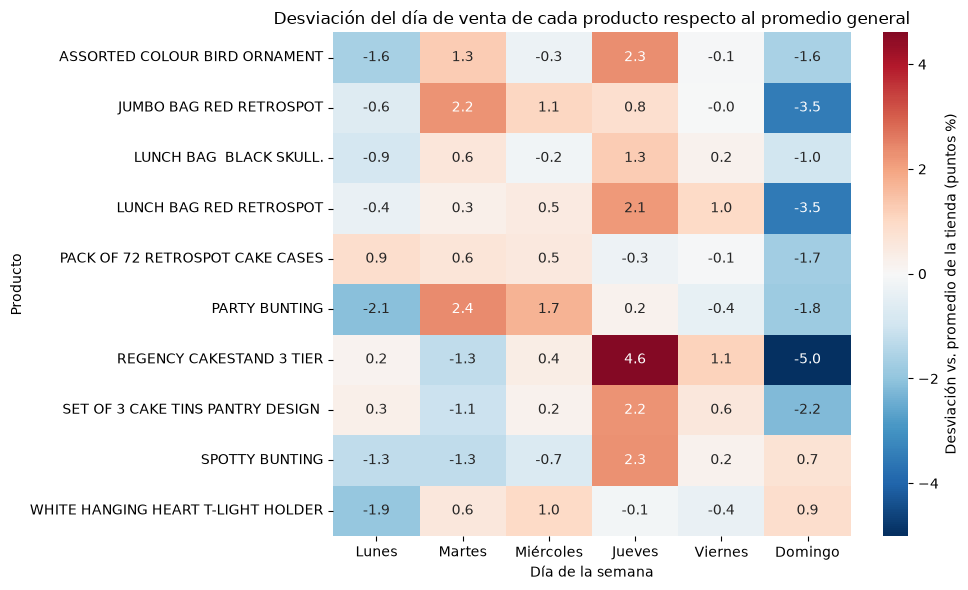

In [141]:
# Heatmap de los 10 productos más pedidos por día de la semana (sin sábado), en porcentaje
codigos_excluir = ['POST', 'DOT', 'M', 'BANK CHARGES', 'AMAZONFEE', 'CRUK', 'PADS', 'C2']
# Asegurar que consumer_data y columnas necesarias existan, sin sobrescribir si ya están
if 'consumer_data' not in globals():
    consumer_data = pd.read_excel('data/Online Retail.xlsx')

# Asegurar que Fecha_compra sea datetime
if not pd.api.types.is_datetime64_any_dtype(consumer_data.get('Fecha_compra')):
    consumer_data['Fecha_compra'] = pd.to_datetime(consumer_data['Fecha_compra'], errors='coerce')

# Crear Dia_semana si no existe
if 'Dia_semana' not in consumer_data.columns:
    dias_es = {0:'Lunes',1:'Martes',2:'Miércoles',3:'Jueves',4:'Viernes',5:'Sábado',6:'Domingo'}
    consumer_data['Dia_semana'] = consumer_data['Fecha_compra'].dt.dayofweek.map(dias_es)

# Filtrar códigos a excluir y eliminar sábados (según tu comentario "sin sábado")
datos_productos = consumer_data[~consumer_data['Cod_prod'].isin(codigos_excluir)].copy()
datos_productos = datos_productos[datos_productos['Dia_semana'] != 'Sábado']
top10 = datos_productos['Nombre_Producto'].value_counts().head(10).index
tabla = datos_productos[datos_productos['Nombre_Producto'].isin(top10)]

# % por producto y día (como ya tenías)
pct_producto_dia = pd.crosstab(tabla['Nombre_Producto'], tabla['Dia_semana'], normalize='index') * 100

# Línea base: % global por día, sobre TODA la tienda (sin filtrar a top10)
pct_global_dia = consumer_data['Dia_semana'].value_counts(normalize=True) * 100

# Índice de desviación: >0 significa que ese producto se vende más ese día de lo esperado
desviacion = pct_producto_dia.sub(pct_global_dia, axis=1)

productos_top10 = (
    datos_productos.groupby('Nombre_Producto')['Numero_factura']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .index
)

producto_semana_top10 = (
    datos_productos[datos_productos['Nombre_Producto'].isin(productos_top10)]
    .pivot_table(index='Nombre_Producto', columns='Dia_semana', values='Numero_factura', aggfunc='nunique', fill_value=0)
)

orden_dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Domingo']
desviacion = desviacion.reindex(columns=orden_dias)

producto_semana_top10_pct = producto_semana_top10.div(producto_semana_top10.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10, 6))
sns.heatmap(desviacion, annot=True, fmt='.1f', cmap='RdBu_r', center=0,
            cbar_kws={'label': 'Desviación vs. promedio de la tienda (puntos %)'})
plt.title('Desviación del día de venta de cada producto respecto al promedio general')
plt.xlabel('Día de la semana')
plt.ylabel('Producto')
plt.tight_layout()
plt.show()

Datos relevantes

In [142]:
fecha_corte = consumer_data['Fecha_compra'].max() + pd.Timedelta(days=1)

fecha_corte = consumer_data['Fecha_compra'].max() + pd.Timedelta(days=1)

if 'Monto' not in consumer_data.columns:
    consumer_data['Monto'] = consumer_data['Cantidad'] * consumer_data['Precio unitario']

rfm = consumer_data.groupby('Cod_Cliente').agg(
    Recency=('Fecha_compra', lambda x: (fecha_corte - x.max()).days),
    Frequency=('Numero_factura', 'nunique'),
    Monetary=('Monto', 'sum'),
    Diversidad_productos=('Cod_prod', 'nunique'),
    Pais=('País', 'first')
).reset_index()

rfm['Ticket_promedio'] = rfm['Monetary'] / rfm['Frequency']
if 'Estado de la compra' not in consumer_data.columns:
    consumer_data['Estado de la compra'] = np.where(
        consumer_data['Numero_factura'].astype(str).str.contains('C', case=False, na=False),
        'Cancelado',
        'Realizado'
    )

rfm['Tasa_cancelacion'] = consumer_data.groupby('Cod_Cliente')['Estado de la compra'] \
    .apply(lambda x: (x == 'Cancelado').mean()).values

rfm['Ticket_promedio'] = rfm['Monetary'] / rfm['Frequency']
rfm['Tasa_cancelacion'] = consumer_data.groupby('Cod_Cliente')['Estado de la compra'] \
    .apply(lambda x: (x == 'Cancelado').mean()).values

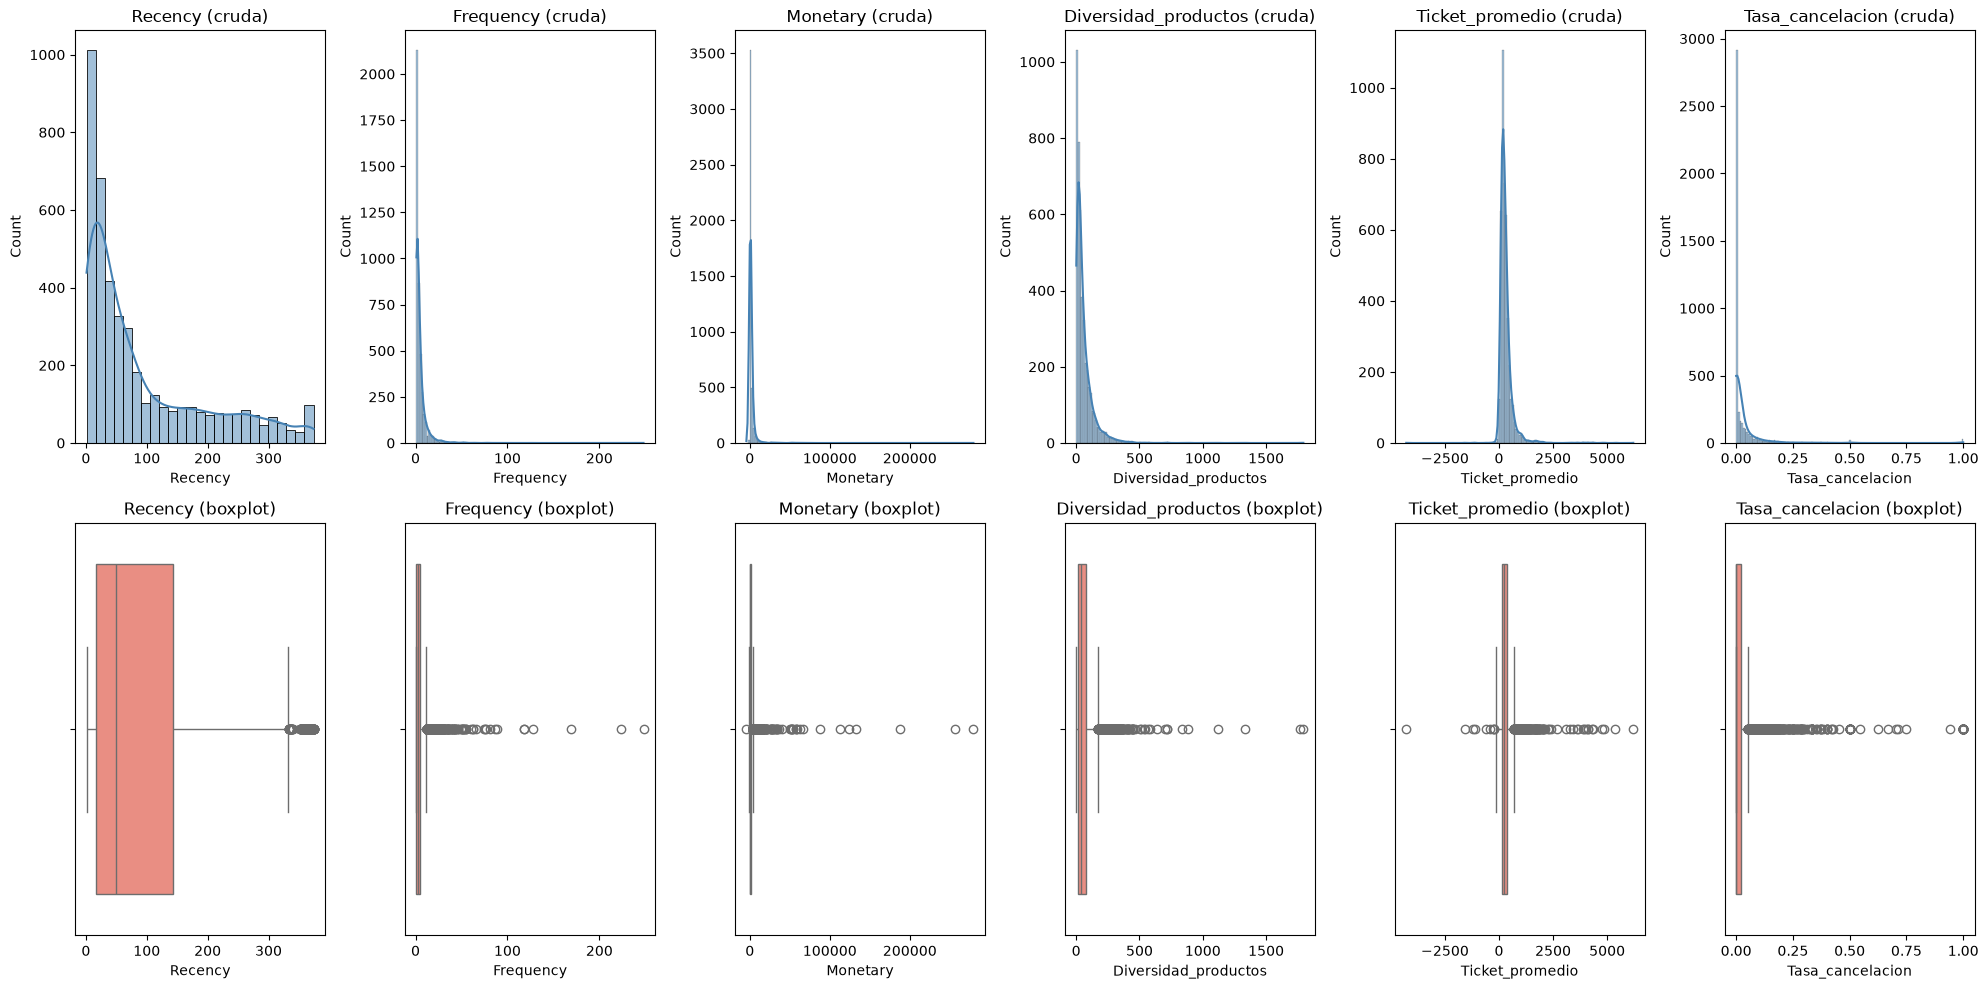

In [143]:

variables = ['Recency', 'Frequency', 'Monetary', 'Diversidad_productos', 'Ticket_promedio', 'Tasa_cancelacion']

fig, axes = plt.subplots(2, 6, figsize=(20, 10))

for i, col in enumerate(variables):
    # Fila 1: distribución cruda
    sns.histplot(rfm[col], kde=True, ax=axes[0, i], color='steelblue')
    axes[0, i].set_title(f'{col} (cruda)')

    # Fila 2: boxplot crudo, para ver outliers de un vistazo
    sns.boxplot(x=rfm[col], ax=axes[1, i], color='salmon')
    axes[1, i].set_title(f'{col} (boxplot)')

plt.tight_layout()
plt.show()

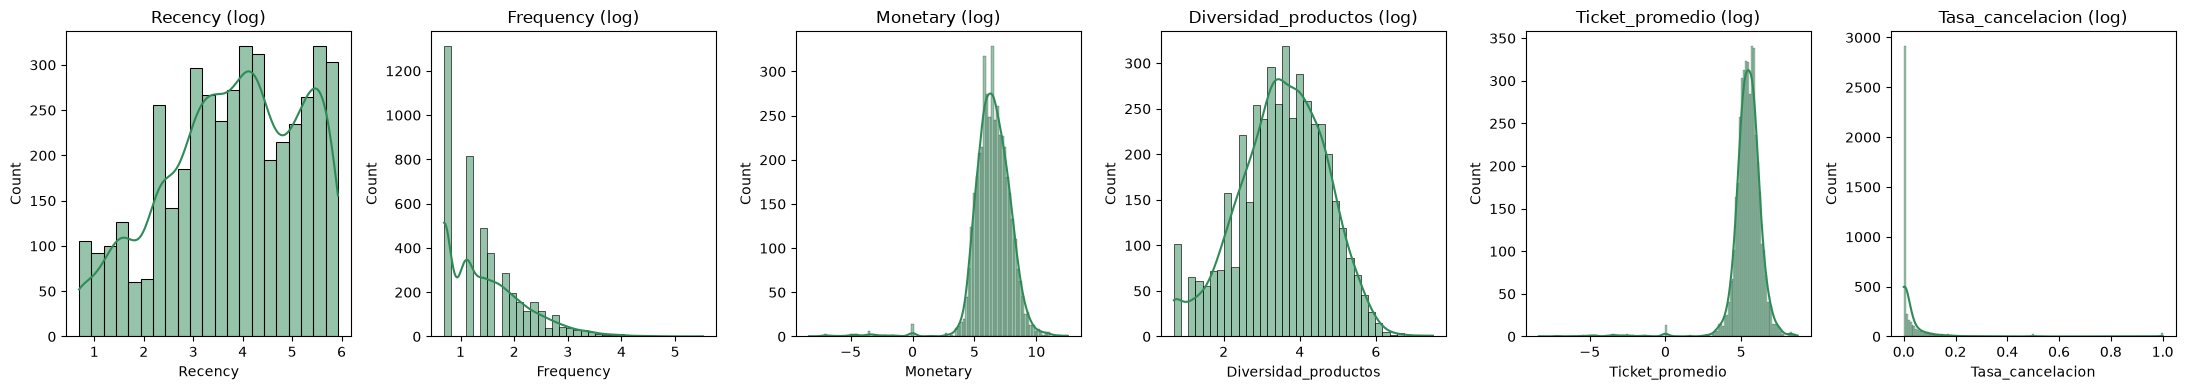

In [144]:
def log_signed(x):
    return np.sign(x) * np.log1p(np.abs(x))

rfm_log = rfm.copy()
for col in ['Recency', 'Frequency', 'Diversidad_productos']:
    rfm_log[col] = np.log1p(rfm[col])
for col in ['Monetary', 'Ticket_promedio']:
    rfm_log[col] = log_signed(rfm[col])

fig, axes = plt.subplots(1, 6, figsize=(22, 4))
for i, col in enumerate(variables):
    sns.histplot(rfm_log[col], kde=True, ax=axes[i], color='seagreen')
    axes[i].set_title(f'{col} (log)')
plt.tight_layout()
plt.show()

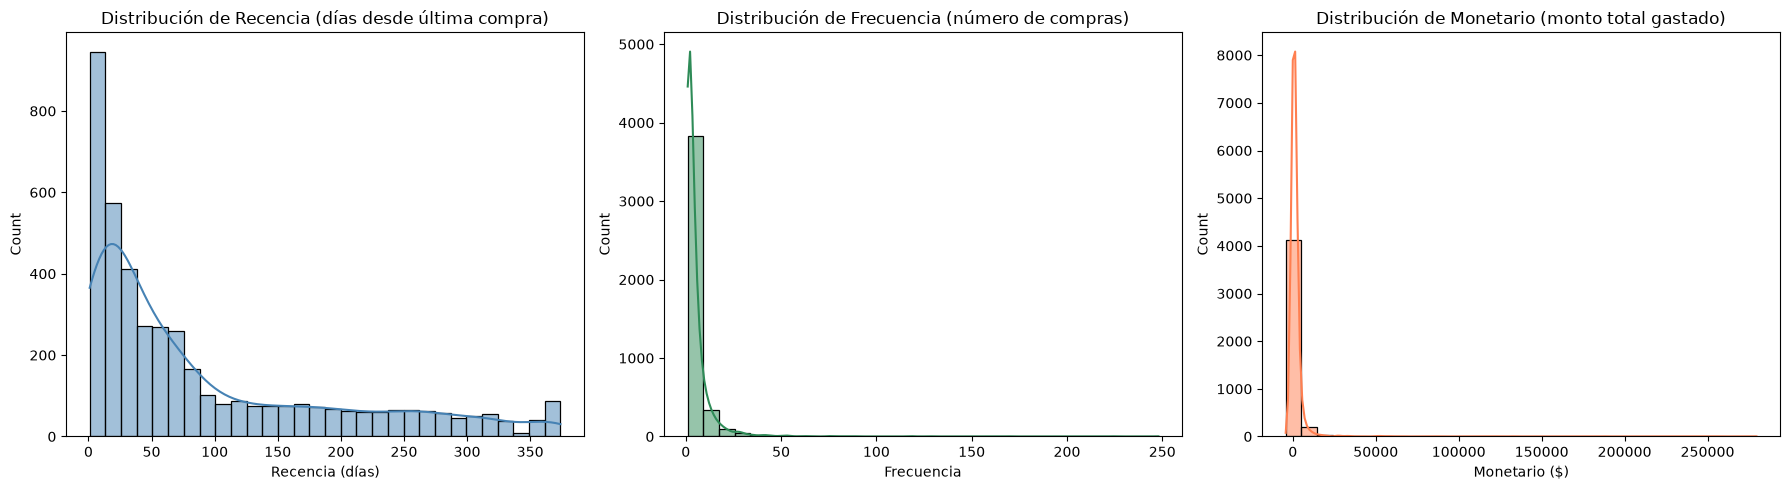

In [145]:
# Gráficos de distribuciones individuales RFM
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Recencia
sns.histplot(rfm['Recency'], kde=True, ax=axes[0], color='steelblue', bins=30)
axes[0].set_title('Distribución de Recencia (días desde última compra)')
axes[0].set_xlabel('Recencia (días)')

# Frecuencia
sns.histplot(rfm['Frequency'], kde=True, ax=axes[1], color='seagreen', bins=30)
axes[1].set_title('Distribución de Frecuencia (número de compras)')
axes[1].set_xlabel('Frecuencia')

# Monetario
sns.histplot(rfm['Monetary'], kde=True, ax=axes[2], color='coral', bins=30)
axes[2].set_title('Distribución de Monetario (monto total gastado)')
axes[2].set_xlabel('Monetario ($)')

plt.tight_layout()
plt.show()


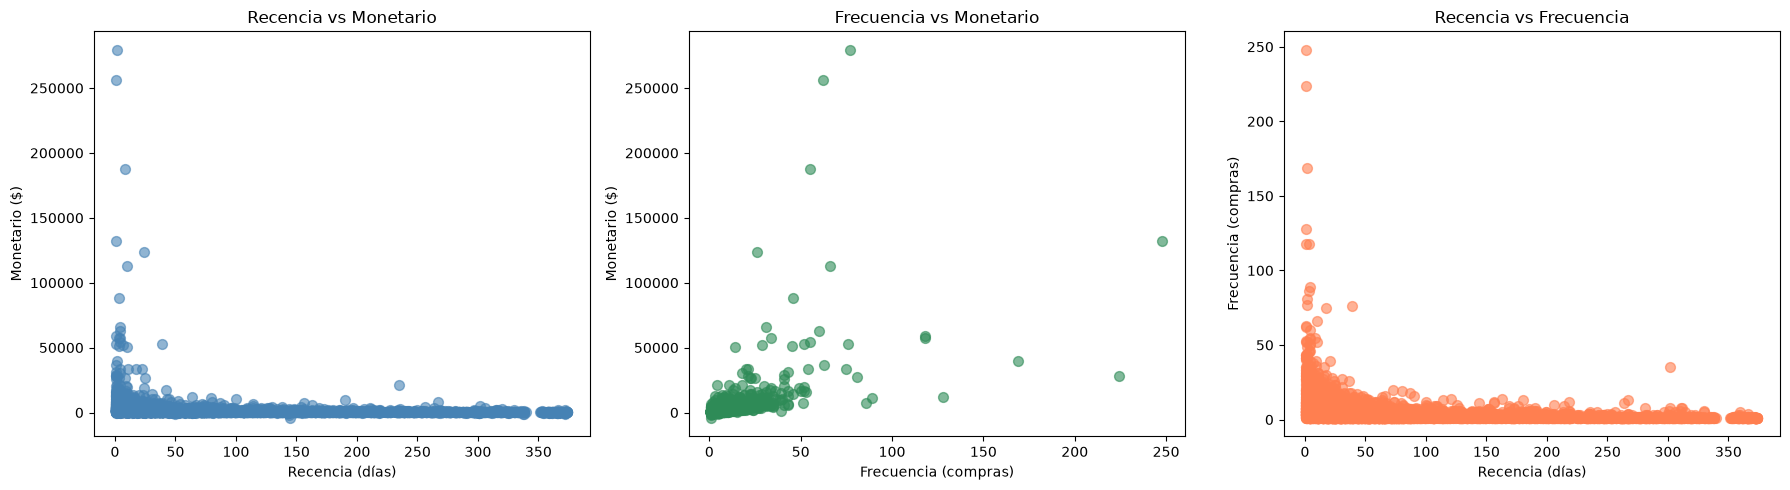

In [146]:
# Scatter plots de relaciones RFM
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Recency vs Monetary
axes[0].scatter(rfm['Recency'], rfm['Monetary'], alpha=0.6, s=50, color='steelblue')
axes[0].set_xlabel('Recencia (días)')
axes[0].set_ylabel('Monetario ($)')
axes[0].set_title('Recencia vs Monetario')

# Frecuencia vs Monetary
axes[1].scatter(rfm['Frequency'], rfm['Monetary'], alpha=0.6, s=50, color='seagreen')
axes[1].set_xlabel('Frecuencia (compras)')
axes[1].set_ylabel('Monetario ($)')
axes[1].set_title('Frecuencia vs Monetario')

# Recency vs Frecuencia
axes[2].scatter(rfm['Recency'], rfm['Frequency'], alpha=0.6, s=50, color='coral')
axes[2].set_xlabel('Recencia (días)')
axes[2].set_ylabel('Frecuencia (compras)')
axes[2].set_title('Recencia vs Frecuencia')

plt.tight_layout()
plt.show()


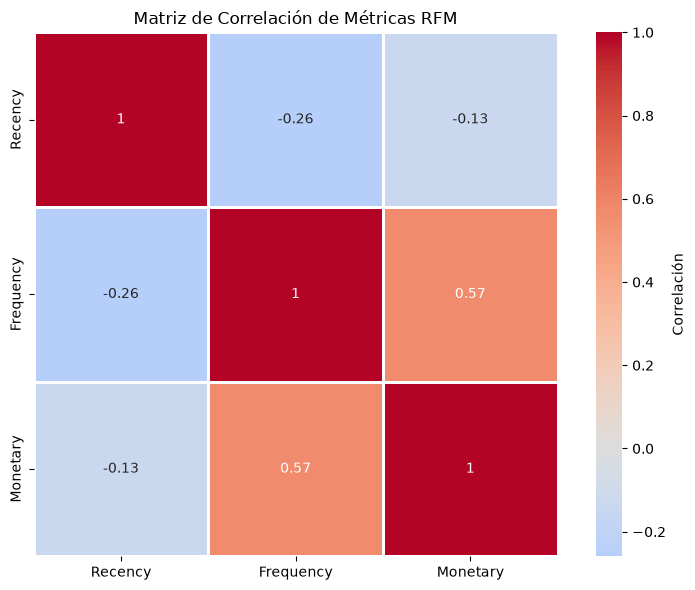

Estadísticas descriptivas de RFM:
           Recency    Frequency       Monetary
count  4372.000000  4372.000000    4372.000000
mean     92.047118     5.075480    1893.531433
std     100.765435     9.338754    8218.696204
min       1.000000     1.000000   -4287.630000
25%      17.000000     1.000000     291.795000
50%      50.000000     3.000000     644.070000
75%     143.000000     5.000000    1608.335000
max     374.000000   248.000000  279489.020000


In [147]:
# Matriz de correlación RFM
fig, ax = plt.subplots(figsize=(8, 6))
rfm_metricas = rfm[['Recency', 'Frequency', 'Monetary']]
correlacion = rfm_metricas.corr()
sns.heatmap(correlacion, annot=True, cmap='coolwarm', center=0, ax=ax, 
            square=True, linewidths=1, cbar_kws={'label': 'Correlación'})
ax.set_title('Matriz de Correlación de Métricas RFM')
axes[0].set_xlabel('Recencia (días)')
axes[0].set_ylabel('Frecuencia (compras)')
plt.tight_layout()
plt.show()

# Estadísticas descriptivas
print("Estadísticas descriptivas de RFM:")
print(rfm[['Recency', 'Frequency', 'Monetary']].describe())


# Introduciión a Algoritmos no supervisados

In [148]:
clientes_df = consumer_data_a.groupby('Cod_Cliente')[['Numero_factura']].nunique()
clientes_df.rename(columns={'Numero_factura': 'num_orders'},inplace=True)
#clientes_df['Dia_semana'] = pd.to_datetime(consumer_data_a['Fecha_compra']).date.dt.day_name()
clientes_df
#consumer_data_a


,num_orders
Cod_Cliente,
12346.0,2
12347.0,7
12348.0,4
12349.0,1
12350.0,1
...,...
18280.0,1
18281.0,1
18282.0,3


Clientes con una sola compra (sin intervalo definido): 1313 de 4372


,Cod_Cliente,Recency,Frequency,Monetary,Diversidad_productos,Pais,Ticket_promedio,Tasa_cancelacion,Dias_promedio_entre_compras
0,12346.0,326,2,0.00,1,United Kingdom,0.000000,0.500000,0.000000
1,12347.0,2,7,4310.00,103,Iceland,615.714286,0.000000,60.333333
2,12348.0,75,4,1797.24,22,Finland,449.310000,0.000000,94.000000
3,12349.0,19,1,1757.55,73,Italy,1757.550000,0.000000,NaN
4,12350.0,310,1,334.40,17,Norway,334.400000,0.000000,NaN
...,...,...,...,...,...,...,...,...,...
4367,18280.0,278,1,180.60,10,United Kingdom,180.600000,0.000000,NaN
4368,18281.0,181,1,80.82,7,United Kingdom,80.820000,0.000000,NaN
4369,18282.0,8,3,176.60,12,United Kingdom,58.866667,0.076923,59.000000
4370,18283.0,4,16,2045.53,263,United Kingdom,127.845625,0.000000,21.800000


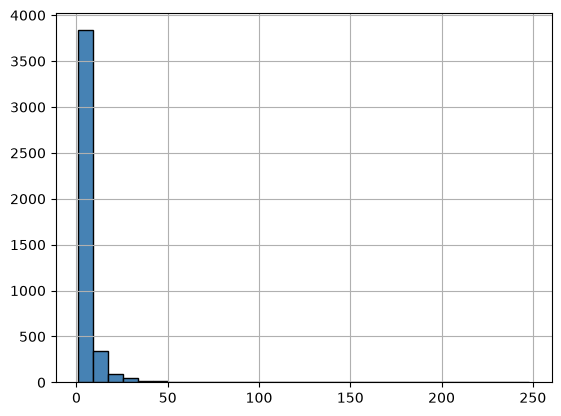

In [149]:
# Una fecha por factura (no por línea de producto)
fechas_por_factura = consumer_data.groupby(['Cod_Cliente', 'Numero_factura'])['Fecha_compra'].min().reset_index()
fechas_por_factura = fechas_por_factura.sort_values(['Cod_Cliente', 'Fecha_compra'])

def promedio_dias(grupo):
    if len(grupo) < 2:
        return np.nan
    return grupo['Fecha_compra'].diff().dropna().dt.days.mean()

dias_entre_compras = fechas_por_factura.groupby('Cod_Cliente').apply(promedio_dias)
rfm['Dias_promedio_entre_compras'] = rfm['Cod_Cliente'].map(dias_entre_compras)

print(f"Clientes con una sola compra (sin intervalo definido): {rfm['Dias_promedio_entre_compras'].isna().sum()} de {len(rfm)}")
clientes_df['num_orders'].hist(bins=30, color='steelblue', edgecolor='black')
clientes_df['avg_time_between_orders'] = rfm['Dias_promedio_entre_compras']
rfm

In [150]:
clientes_df['avg_products_per_order'] = consumer_data_a.groupby('Cod_Cliente')['Cod_prod'].count()/clientes_df['num_orders']

Frcuencia de Compra

,Cod_Cliente,Recency,Frequency,Monetary,Diversidad_productos,Pais,Ticket_promedio,Tasa_cancelacion,Dias_promedio_entre_compras
0,12346.0,326,2,0.00,1,United Kingdom,0.000000,0.500000,0.000000
1,12347.0,2,7,4310.00,103,Iceland,615.714286,0.000000,60.333333
2,12348.0,75,4,1797.24,22,Finland,449.310000,0.000000,94.000000
3,12349.0,19,1,1757.55,73,Italy,1757.550000,0.000000,NaN
4,12350.0,310,1,334.40,17,Norway,334.400000,0.000000,NaN
...,...,...,...,...,...,...,...,...,...
4367,18280.0,278,1,180.60,10,United Kingdom,180.600000,0.000000,NaN
4368,18281.0,181,1,80.82,7,United Kingdom,80.820000,0.000000,NaN
4369,18282.0,8,3,176.60,12,United Kingdom,58.866667,0.076923,59.000000
4370,18283.0,4,16,2045.53,263,United Kingdom,127.845625,0.000000,21.800000


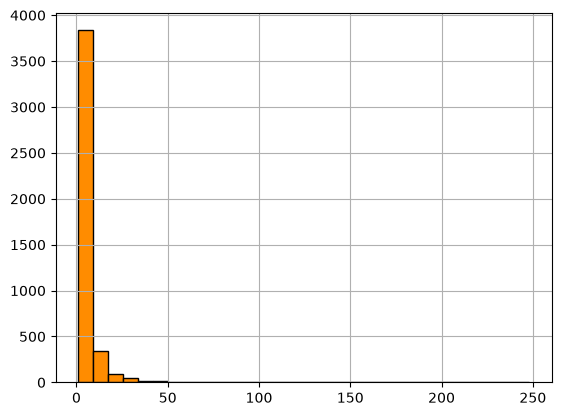

In [151]:
clientes_df['num_orders'].hist(bins=30, color='darkorange', edgecolor='black')
#clientes_df['Cod_Cliente'] = clientes_df.count()
clientes_df
rfm

# Clusterización

In [152]:
# Importamos las librerías
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import calinski_harabasz_score
from sklearn.preprocessing import StandardScaler

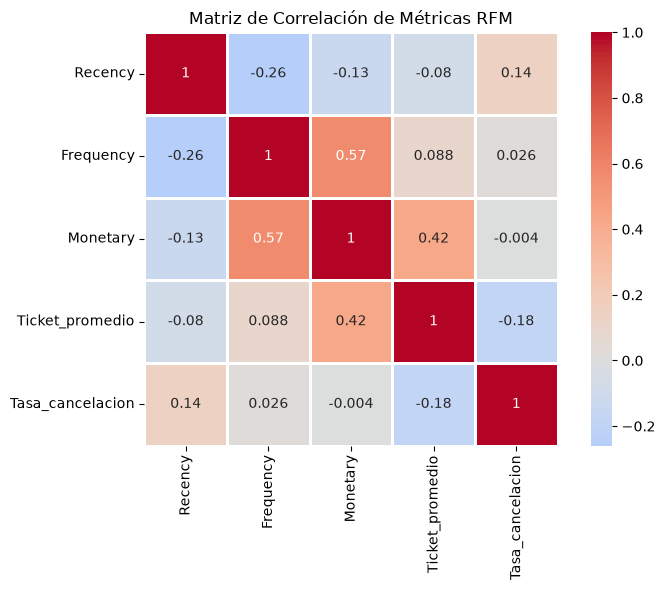

In [153]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(rfm[['Recency','Frequency','Monetary','Ticket_promedio','Tasa_cancelacion']].corr(), annot=True, cmap='coolwarm', center=0, ax=ax, square=True, linewidths=1)
ax.set_title('Matriz de Correlación de Métricas RFM')
plt.tight_layout()
plt.show()

In [154]:
def log_signed(x):
    return np.sign(x) * np.log1p(np.abs(x))

cols_finales = ['Recency', 'Frequency', 'Monetary', 'Ticket_promedio', 'Tasa_cancelacion']
rfm_log = rfm.copy()
rfm_log['Recency'] = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary'] = log_signed(rfm_log['Monetary'])
rfm_log['Ticket_promedio'] = log_signed(rfm_log['Ticket_promedio'])
# Tasa_cancelacion ya está en [0,1], no necesita log

scalar = StandardScaler()
scaled_data = scalar.fit_transform(rfm_log[cols_finales])

In [155]:

# scaling the data with standardizing the features 
#scalar = StandardScaler()
#scaled_data = scalar.fit_transform(rfm_log[['Recency','Frequency','Monetary','Ticket_promedio','Tasa_cancelacion']]) # ajusta el escalador a los datos y los transforma en un solo paso.

La separación de atípicos antes de clusterizar: no existe en el notebook

In [156]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.012, random_state=42)  # ~54 de 4372 clientes, según lo que vimos antes
rfm_log['Es_atipico'] = iso.fit_predict(scaled_data)  # -1 = atípico, 1 = normal

clientes_atipicos = rfm_log[rfm_log['Es_atipico'] == -1]
rfm_normal = rfm_log[rfm_log['Es_atipico'] == 1].reset_index(drop=True)

print(f"Clientes atípicos separados: {len(clientes_atipicos)}")
print(f"Clientes para segmentación normal: {len(rfm_normal)}")

scaled_normal = scalar.fit_transform(rfm_normal[cols_finales])

Clientes atípicos separados: 53
Clientes para segmentación normal: 4319


# Estimando un cluster ideal


Metodo del códo 

##### La Métrica Clave: Inercia (Within-Cluster Sum of Squares)
La métrica más comúnmente utilizada en el método del codo es la inercia, también conocida como Suma de las distancias al cuadrado dentro de los clústeres (WCSS - Within-Cluster Sum of Squares).

100%|██████████| 10/10 [00:03<00:00,  3.30it/s]


Text(0, 0.5, 'Inercia')

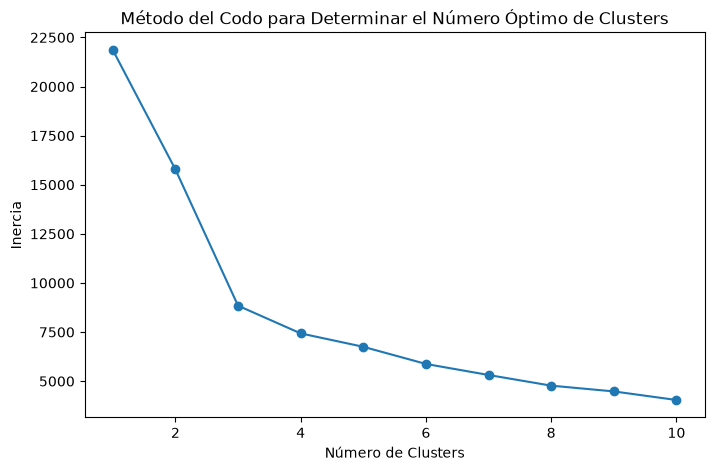

In [157]:
# implementando el método del codo para determinar el número óptimo de clusters
inertia = []
for i in tqdm(range(1, 11)):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Método del Codo para Determinar el Número Óptimo de Clusters')
plt.xlabel('Número de Clusters')
plt.ylabel('Inercia')

### El Índice de Calinski-Harabasz para Evaluar Clústeres
El Índice de Calinski-Harabasz (también conocido como Criterio de Razón de Varianza o VRC) es una métrica utilizada para evaluar la calidad de una solución de clustering. A diferencia del método del codo que se basa en la inspección visual de una curva, este índice proporciona una puntuación numérica que ayuda a determinar el número óptimo de clústeres (k) de una forma más objetiva.

La idea central es que un buen clustering tiene clústeres muy compactos (baja dispersión dentro de los clústeres) y, al mismo tiempo, muy bien separados entre sí (alta dispersión entre los clústeres). El índice de Calinski-Harabasz cuantifica esta relación.


100%|██████████| 9/9 [00:00<00:00, 18.97it/s]


Text(0, 0.5, 'Índice Calinski-Harabasz')

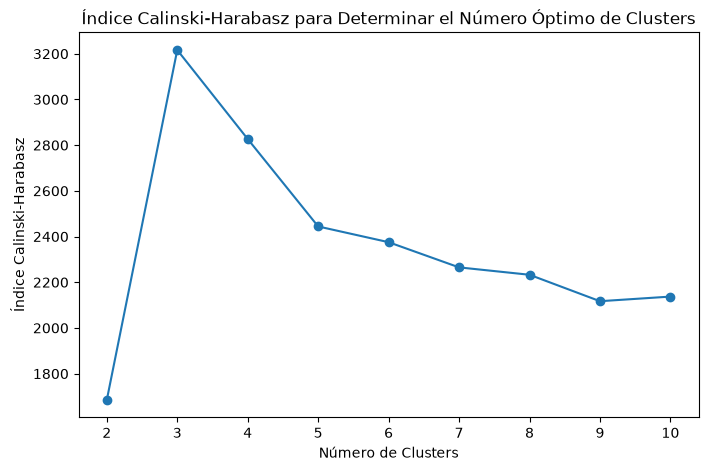

In [158]:
# calculando el índice Calinski-Harabasz para cada número de clusters
CH_scores = []
for i in tqdm(range(2, 11)):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    score = calinski_harabasz_score(scaled_data, kmeans.labels_)
    CH_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), CH_scores, marker='o')
plt.title('Índice Calinski-Harabasz para Determinar el Número Óptimo de Clusters')
plt.xlabel('Número de Clusters')
plt.ylabel('Índice Calinski-Harabasz')

### El Coeficiente Silueta (Silhouette Coefficient)

El **Coeficiente de Silueta** es una métrica utilizada para evaluar la calidad de los resultados de un algoritmo de clustering. Mide qué tan bien agrupado está un objeto en comparación con otros clústeres. En esencia, cuantifica qué tan similar es un punto a su propio clúster (cohesión) en comparación con otros clústeres (separación).

El puntaje varía en un rango de **-1 a 1**.

100%|██████████| 9/9 [00:19<00:00,  2.22s/it]


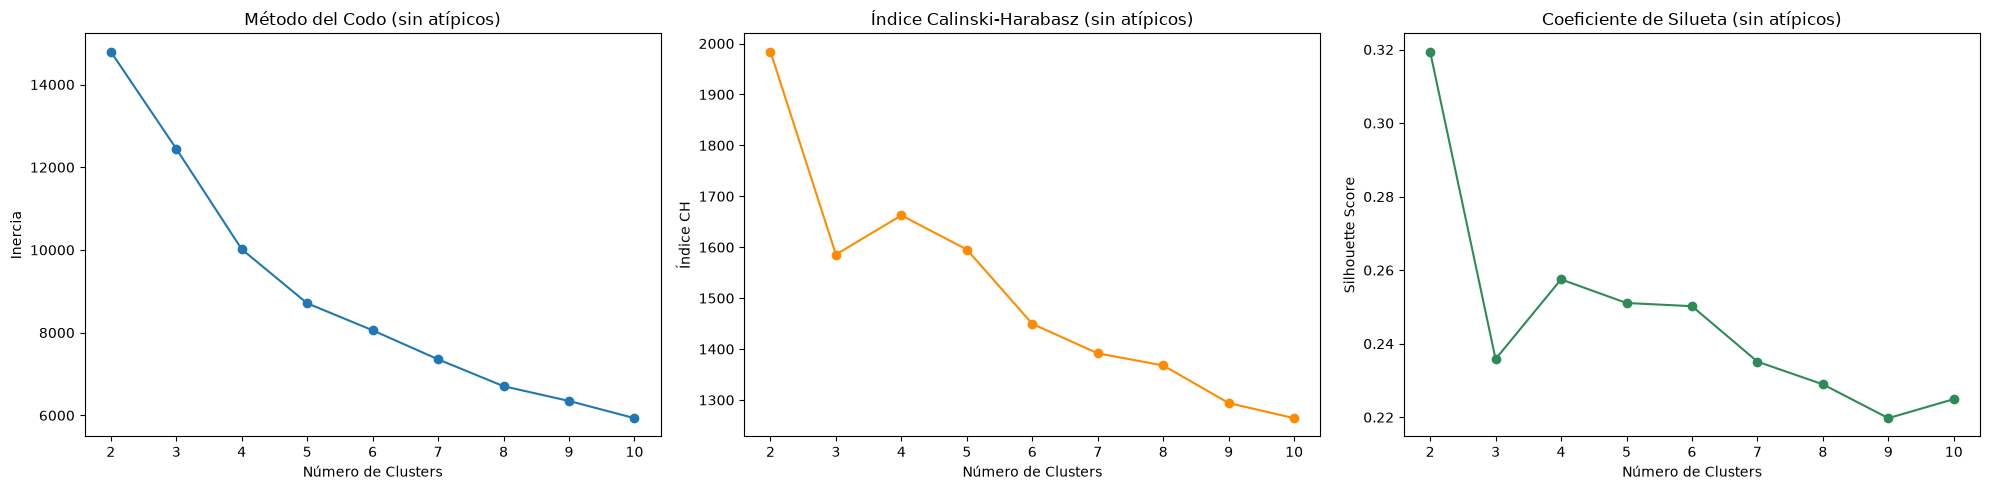

Silhouette en k=4: 0.257


In [159]:
from sklearn.metrics import silhouette_score

# Recalculamos también el codo y Calinski-Harabasz sobre scaled_normal (sin atípicos),
# para que la justificación de k sea consistente con el modelo final
inertia_normal = []
CH_normal = []
silhouette_scores = []

for i in tqdm(range(2, 11)):
    kmeans_tmp = KMeans(n_clusters=i, random_state=42, n_init='auto')
    labels_tmp = kmeans_tmp.fit_predict(scaled_normal)
    inertia_normal.append(kmeans_tmp.inertia_)
    CH_normal.append(calinski_harabasz_score(scaled_normal, labels_tmp))
    silhouette_scores.append(silhouette_score(scaled_normal, labels_tmp))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].plot(range(2, 11), inertia_normal, marker='o')
axes[0].set_title('Método del Codo (sin atípicos)')
axes[0].set_xlabel('Número de Clusters')
axes[0].set_ylabel('Inercia')

axes[1].plot(range(2, 11), CH_normal, marker='o', color='darkorange')
axes[1].set_title('Índice Calinski-Harabasz (sin atípicos)')
axes[1].set_xlabel('Número de Clusters')
axes[1].set_ylabel('Índice CH')

axes[2].plot(range(2, 11), silhouette_scores, marker='o', color='seagreen')
axes[2].set_title('Coeficiente de Silueta (sin atípicos)')
axes[2].set_xlabel('Número de Clusters')
axes[2].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

print(f"Silhouette en k=4: {silhouette_scores[2]:.3f}")

### Ejecutando k-Means con k=4
Implementemos ahora el algoritmo y analicemos sus resultados

In [160]:
# 1. Entrenar el K-means y obtener las etiquetas
km4 = KMeans(n_clusters=4, random_state=42, n_init='auto')
kmeans_labels_rfm = km4.fit_predict(scaled_normal)
rfm_normal['Cluster'] = kmeans_labels_rfm

# 2. Traer los valores crudos (sin log) usando Cod_Cliente como llave
rfm_crudo = rfm.set_index('Cod_Cliente')
rfm_perfil = rfm_crudo.loc[rfm_normal['Cod_Cliente']].reset_index()
rfm_perfil['Cluster'] = kmeans_labels_rfm

# 3. Calcular el perfil con valores reales
perfil = rfm_perfil.groupby('Cluster')[['Recency','Frequency','Monetary','Ticket_promedio','Tasa_cancelacion']].mean().round(1)
print(perfil)
print(rfm_perfil['Cluster'].value_counts())

         Recency  Frequency  Monetary  Ticket_promedio  Tasa_cancelacion
Cluster                                                                 
0          108.1        2.2     969.6            480.7               0.0
1          135.4        1.9     260.6            143.4               0.0
2           19.8       11.6    4638.6            351.2               0.0
3          116.3        4.9     880.9            167.7               0.2
Cluster
0    1438
1    1404
2    1314
3     163
Name: count, dtype: int64


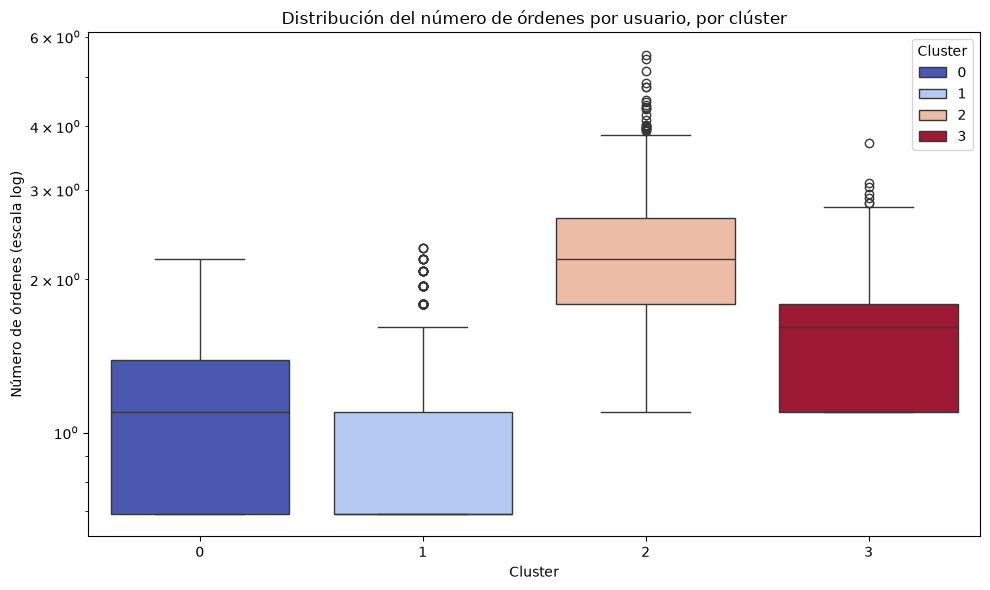

In [161]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cluster', y='Frequency', hue='Cluster', data=rfm_normal,
            palette='coolwarm', legend=True)
plt.yscale('log')
plt.ylabel('Número de órdenes (escala log)')
plt.title('Distribución del número de órdenes por usuario, por clúster')
plt.tight_layout()
plt.show()

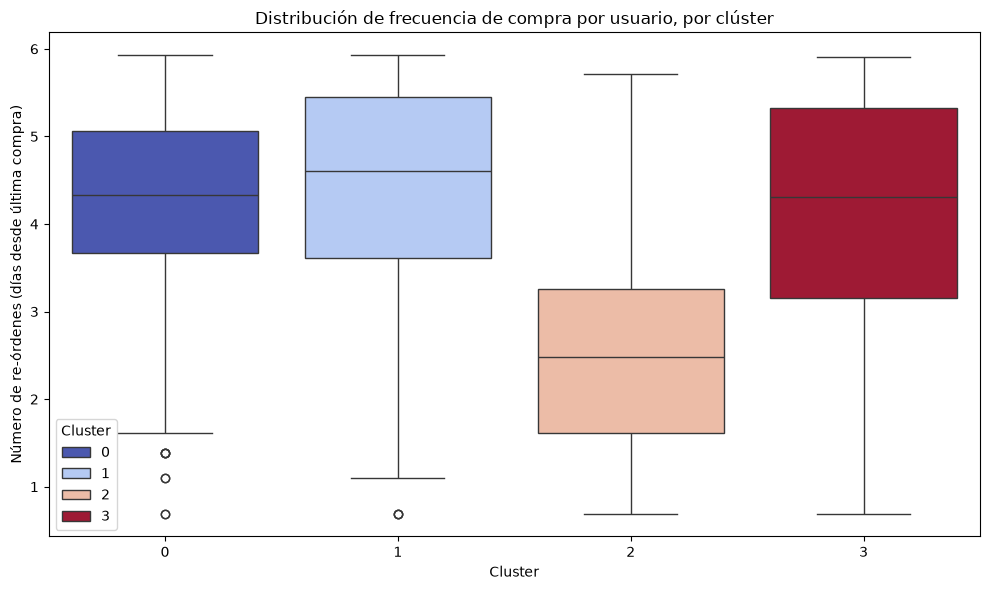

In [162]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cluster', y='Recency', hue='Cluster', data=rfm_normal,
            palette='coolwarm', legend=True)
#plt.yscale('log')
plt.ylabel('Número de re-órdenes (días desde última compra)')
plt.title('Distribución de frecuencia de compra por usuario, por clúster')
plt.tight_layout()
plt.show()


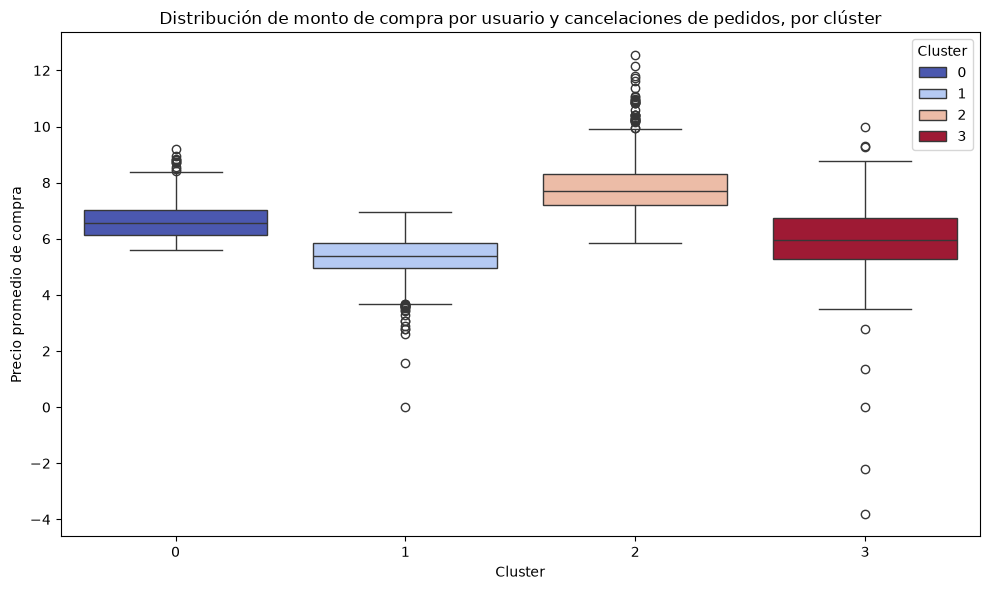

In [163]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cluster', y='Monetary', hue='Cluster', data=rfm_normal,
            palette='coolwarm', legend=True)
#plt.yscale('log')
plt.ylabel('Precio promedio de compra')
plt.title('Distribución de monto de compra por usuario y cancelaciones de pedidos, por clúster')
plt.tight_layout()
plt.show()

Se analiza en 3d las tres variables

In [164]:
import plotly.graph_objs as go


rfm_crudo = rfm.set_index('Cod_Cliente')

fig = go.Figure(data=[go.Scatter3d(
    x=rfm_normal['Cod_Cliente'].map(rfm_crudo['Frequency']),
    y=rfm_normal['Dias_promedio_entre_compras'],
    z=rfm_normal['Cod_Cliente'].map(rfm_crudo['Diversidad_productos']),
    mode='markers',
    marker=dict(
        size=5,
        color=kmeans_labels_rfm,  # Color por clúster
        colorscale='Viridis',
        opacity=0.6
    )
)])

fig.update_layout(
    title='Visualización 3D de los clústeres (Plotly)',
    scene=dict(
        xaxis_title="Número de órdenes",
        yaxis_title="Tiempo promedio entre órdenes (días)",
        zaxis_title="Diversidad de productos"
    ),
    width=800, height=800,
   
)
fig.update_layout(scene=dict(xaxis_type='log', zaxis_type='log'))
fig.show()

nbformat

# Clusterización con DB-SCAN

In [165]:
# implementando el algoritmo DBSCAN para clusterizar los datos
from sklearn.cluster import DBSCAN
epss = [0.5,0.6,0.7,0.8,0.9,1.0]
for eps in epss:
    # creando un objeto DBSCAN
    dbscan = DBSCAN(eps=eps, min_samples=7)
    # ajustando el modelo a los datos escalados
    dbscan.fit(scaled_normal)
    # obteniendo las etiquetas de los clusters
    dbscan_labels = dbscan.labels_
    # imprimiendo el número de clusters encontrados
    n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
    print(f'Epsilon: {eps}, Número de clusters: {n_clusters}')

Epsilon: 0.5, Número de clusters: 4
Epsilon: 0.6, Número de clusters: 2
Epsilon: 0.7, Número de clusters: 4
Epsilon: 0.8, Número de clusters: 1
Epsilon: 0.9, Número de clusters: 2
Epsilon: 1.0, Número de clusters: 1


In [166]:
# creando un objeto DBSCAN
dbscan = DBSCAN(eps=0.9, min_samples=7)
# ajustando el modelo a los datos escalados
dbscan.fit(scaled_normal)
# obteniendo las etiquetas de los clusters
dbscan_labels = dbscan.labels_

In [167]:
print('Los labels creados', np.unique(dbscan_labels))
print('Distribución de los labels', pd.Series(dbscan_labels).value_counts())

Los labels creados [-1  0  1]
Distribución de los labels  0    4166
-1     143
 1      10
Name: count, dtype: int64


Con eps=0.9, DBSCAN encuentra solo 2 clústeres reales (0 y 1) más el grupo de ruido (-1): 4,166 clientes en el clúster 0, 10 en el clúster 1, y 143 marcados como ruido/anomalías. Esto sugiere que el espacio RFM no tiene densidades bien separadas — es más un continuo que grupos discretos, lo cual es consistente con el silhouette score bajo que obtuvimos en el K-means.

In [168]:
import plotly.graph_objs as go

fig = go.Figure(data=[go.Scatter3d(
    x=rfm_perfil['Frequency'],
    y=rfm_perfil['Recency'],
    z=rfm_crudo.loc[rfm_normal['Cod_Cliente'], 'Diversidad_productos'].values,
    mode='markers',
    marker=dict(
        size=5,
        color=dbscan_labels,
        colorscale='Viridis',
        opacity=0.8,
        colorbar=dict(title='Cluster (DBSCAN)')
    ),
)])

fig.update_layout(
    title='Visualización 3D de los clusters DBSCAN (Plotly)',
    scene=dict(
        xaxis_title="Número de órdenes",
        yaxis_title="Recencia (días)",
        zaxis_title="Diversidad de productos"
    ),
    width=800, height=800,
)
fig.update_layout(scene=dict(xaxis_type='log', zaxis_type='log'))
fig.show()

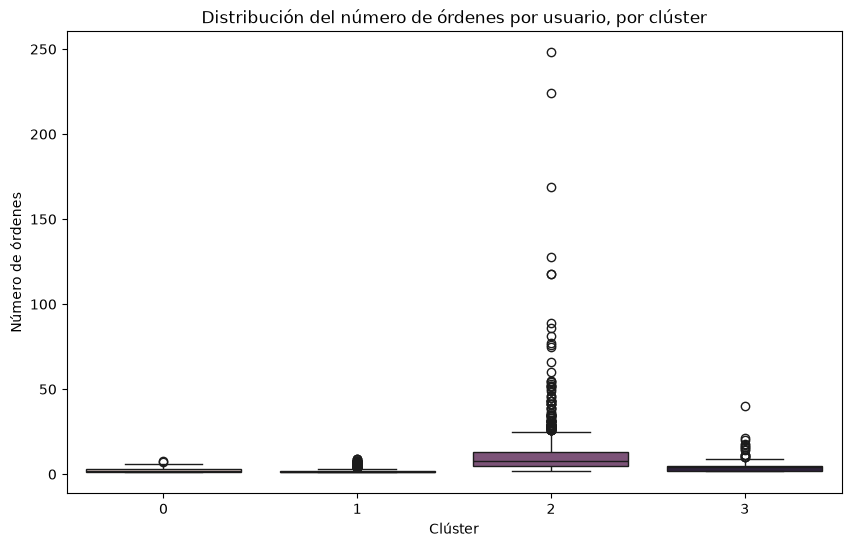

In [169]:
# graficando la distribución del nùmero de órdenes por usuario para cada cluster
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cluster', y='Frequency', hue='Cluster', data=rfm_perfil, legend=False)
plt.xlabel('Clúster')
plt.ylabel('Número de órdenes')
plt.title('Distribución del número de órdenes por usuario, por clúster')
plt.show()

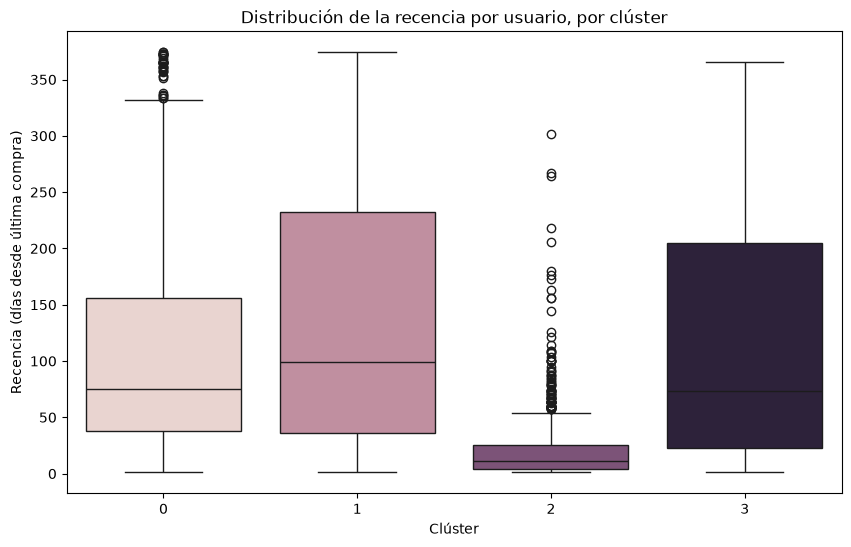

In [170]:
# graficando la distribución del tiempo entre órdenes promedio para cada cluster
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cluster', y='Recency', hue='Cluster', data=rfm_perfil, legend=False)
plt.xlabel('Clúster')
plt.ylabel('Recencia (días desde última compra)')
plt.title('Distribución de la recencia por usuario, por clúster')
plt.show()

# Aplicando PCA para reducir y cambiar las variables

Text(0, 0.5, 'Varianza Acumulada Explicada')

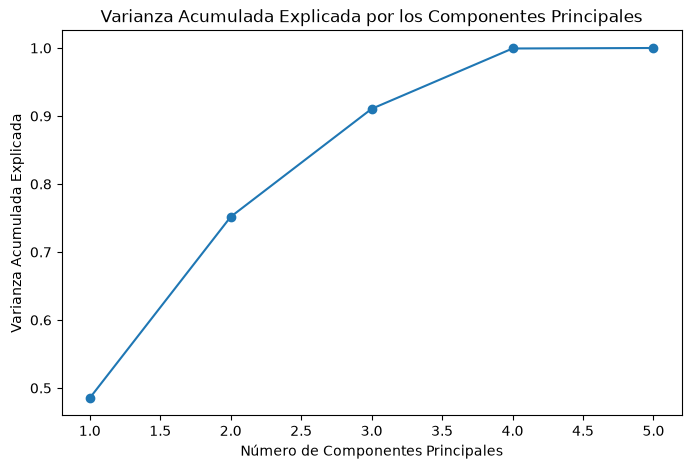

In [171]:
# calculando la varianza acomulada explicada en función del número de componentes principales
pca = PCA()
pca.fit(scaled_normal)
# graficando la varianza acumulada explicada
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_.cumsum(), marker='o')
plt.title('Varianza Acumulada Explicada por los Componentes Principales')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Acumulada Explicada')

In [172]:
# transformando los datos originales a las componentes principales
pca = PCA(n_components=3)
pca_data = pca.fit_transform(scaled_normal)

In [173]:
# haciendo kmeans con las componentes principales
kmeans_pca = KMeans(n_clusters=3, n_init='auto', random_state=42)
kmeans_labels_pca = kmeans_pca.fit_predict(pca_data)

In [174]:
fig = go.Figure(data=[go.Scatter3d(
    x=pca_data[:,0],
    y=pca_data[:,1],
    z=pca_data[:,2],
    mode='markers',
    marker=dict(
        size=5,
        color=kmeans_labels_pca, # color por cluster
        colorscale='Viridis',
        opacity=0.8,
        colorbar=dict(
            title='Cluster'  # Título de la leyenda
        )
    ),
    showlegend=False,  # No aplica para Scatter3d, pero puedes dejarlo
)])

fig.update_layout(
    title='Visualización 3D de los clusters, en el espacio de componentes principales (Plotly)',
    scene=dict(
        xaxis_title="pc1",
        yaxis_title="pc2",
        zaxis_title="pc3"
    ),
    width=800,
    height=800,
)

In [175]:
fig = go.Figure(data=[go.Scatter3d(
    x=rfm_perfil['Frequency'],
    y=rfm_perfil['Recency'],
    z=rfm_crudo.loc[rfm_normal['Cod_Cliente'], 'Diversidad_productos'].values,
    mode='markers',
    marker=dict(size=5, color=kmeans_labels_pca, colorscale='Viridis', opacity=0.8,
                colorbar=dict(title='Cluster (PCA + K-means)')),
)])
fig.update_layout(
    title='Visualización 3D de los clusters sobre componentes principales (Plotly)',
    scene=dict(xaxis_title="Número de órdenes", yaxis_title="Recencia (días)",
               zaxis_title="Diversidad de productos"),
    width=800, height=800,
)
fig.show()

# Detección de anomalías

Intentemos identificar días atípicos, usando el algoritmo de isolation forest, el isolation forest es un algoritmo que nos permite determinar datos atípicos calculando su probabilidad de quedar aislados cuando se ejecuta un árbol de decisión. Como lo que se calcula es una probabilidad de ser atípico, el algoritmo lo único que necesita es una prevalencia esperada de datos atípicos, esta prevalencia se convierte en un número de datos atípicos que el algoritmo escoge ordenando del más probable al menos probable. En nuestro ejercicio, usaremos una prevalencia esperada (contaminación) del 5%.

In [176]:
codigos_especiales = ['POST', 'DOT', 'M', 'BANK CHARGES', 'AMAZONFEE', 'CRUK', 'PADS', 'C2', 'B']

consumer_data_t = consumer_data_a[
    (~consumer_data_a['Cod_prod'].isin(codigos_especiales)) &
    (consumer_data_a['Precio unitario'] > 0)
].copy()

consumer_data_t['Hora_compra'] = pd.to_datetime(consumer_data_t['Fecha_compra']).dt.hour
consumer_data_t['Dia_semana_num'] = pd.to_datetime(consumer_data_t['Fecha_compra']).dt.dayofweek

print(f"Filas para el modelo: {len(consumer_data_t)} (de {len(consumer_data_a)} originales)")

Filas para el modelo: 531376 (de 536641 originales)


In [177]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

features = ['Cantidad', 'Precio unitario', 'Monto', 'Hora_compra', 'Dia_semana_num']
X = consumer_data_t[features]
X_scaled = StandardScaler().fit_transform(X)

iso_transacciones = IsolationForest(contamination=0.05, random_state=42, n_jobs=-1)
consumer_data_t['Anomalia'] = iso_transacciones.fit_predict(X_scaled)
consumer_data_t['Anomaly_score'] = iso_transacciones.decision_function(X_scaled)

n_anom = (consumer_data_t['Anomalia'] == -1).sum()
print(f"Transacciones anómalas detectadas: {n_anom} de {len(consumer_data_t)} ({n_anom/len(consumer_data_t)*100:.2f}%)")
print(consumer_data_t.groupby('Anomalia')[['Cantidad','Precio unitario','Monto']].mean().round(2))

Transacciones anómalas detectadas: 26569 de 531376 (5.00%)
          Cantidad  Precio unitario   Monto
Anomalia                                   
-1           81.71             9.14  148.49
 1            6.18             3.00   11.53


In [178]:
top10 = consumer_data_t[consumer_data_t['Anomalia']==-1].copy()
top10['Monto_abs'] = top10['Monto'].abs()
top10 = top10.sort_values('Monto_abs', ascending=False).head(10)
print(top10[['Numero_factura','Cod_prod','Nombre_Producto','Cantidad','Precio unitario','Monto','Cod_Cliente']])

       Numero_factura Cod_prod                      Nombre_Producto  Cantidad  \
535160         581483    23843          PAPER CRAFT , LITTLE BIRDIE     80995   
61006          541431    23166       MEDIUM CERAMIC TOP STORAGE JAR     74215   
220825         556444    22502       PICNIC BASKET WICKER 60 PIECES        60   
345627         567423    23243  SET OF TEA COFFEE SUGAR TINS PANTRY      1412   
159101         550461    21108   FAIRY CAKE FLANNEL ASSORTED COLOUR      3114   
52169          540815    21108   FAIRY CAKE FLANNEL ASSORTED COLOUR      3114   
418088         573003    23084                   RABBIT NIGHT LIGHT      2400   
52167          540815   85123A   WHITE HANGING HEART T-LIGHT HOLDER      1930   
463639         576365    22086      PAPER CHAIN KIT 50'S CHRISTMAS        688   
159097         550461   85123A   WHITE HANGING HEART T-LIGHT HOLDER      1930   

        Precio unitario      Monto  Cod_Cliente  
535160             2.08  168469.60      16446.0  
61006   

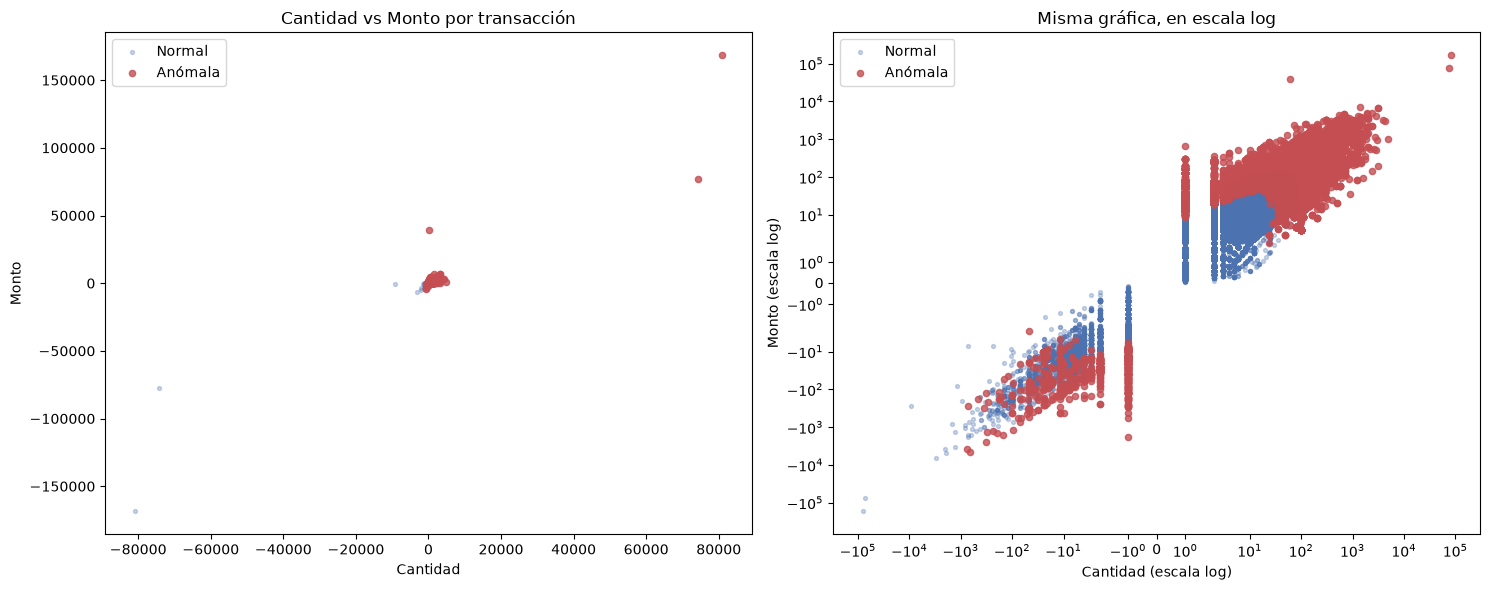

In [179]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

normal = consumer_data_t[consumer_data_t['Anomalia'] == 1]
anomalo = consumer_data_t[consumer_data_t['Anomalia'] == -1]

# Panel 1: escala normal
axes[0].scatter(normal['Cantidad'], normal['Monto'], s=8, alpha=0.3, color='#4C72B0', label='Normal')
axes[0].scatter(anomalo['Cantidad'], anomalo['Monto'], s=20, alpha=0.8, color='#C44E52', label='Anómala')
axes[0].set_xlabel('Cantidad')
axes[0].set_ylabel('Monto')
axes[0].set_title('Cantidad vs Monto por transacción')
axes[0].legend()

# Panel 2: escala log simétrica (admite valores negativos de cancelaciones)
axes[1].scatter(normal['Cantidad'], normal['Monto'], s=8, alpha=0.3, color='#4C72B0', label='Normal')
axes[1].scatter(anomalo['Cantidad'], anomalo['Monto'], s=20, alpha=0.8, color='#C44E52', label='Anómala')
axes[1].set_xscale('symlog')
axes[1].set_yscale('symlog')
axes[1].set_xlabel('Cantidad (escala log)')
axes[1].set_ylabel('Monto (escala log)')
axes[1].set_title('Misma gráfica, en escala log')
axes[1].legend()

plt.tight_layout()
plt.show()

# ValidEación de los resultados con t-SN

In [180]:
print(f"Silhouette K-means sobre PCA (k=3): {silhouette_score(pca_data, kmeans_labels_pca):.3f}")
print(f"Calinski-Harabasz K-means sobre PCA (k=3): {calinski_harabasz_score(pca_data, kmeans_labels_pca):.1f}")
print(f"Varianza explicada por los 3 componentes: {pca.explained_variance_ratio_.sum()*100:.1f}%")

Silhouette K-means sobre PCA (k=3): 0.376
Calinski-Harabasz K-means sobre PCA (k=3): 2021.3
Varianza explicada por los 3 componentes: 91.1%


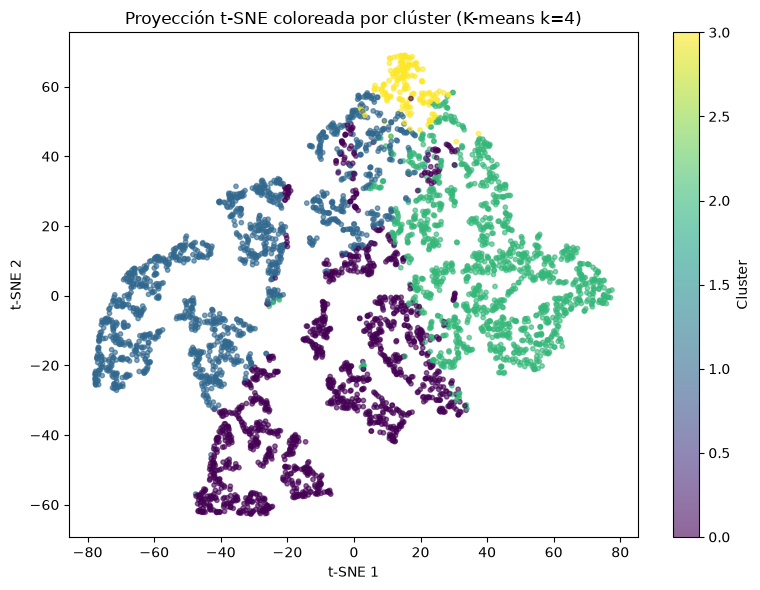

In [181]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca')
embedding_tsne = tsne.fit_transform(scaled_normal)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(embedding_tsne[:,0], embedding_tsne[:,1],
                       c=kmeans_labels_rfm, cmap='viridis', s=10, alpha=0.6)
plt.title('Proyección t-SNE coloreada por clúster (K-means k=4)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

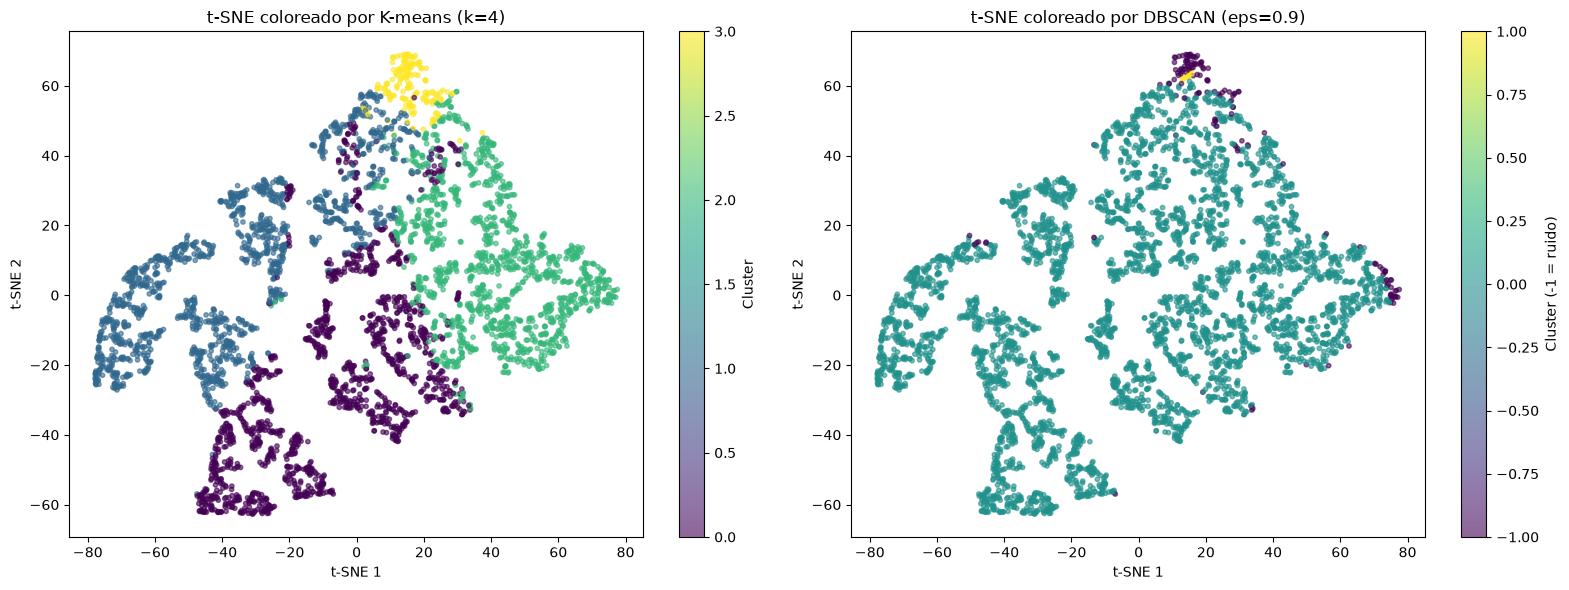

In [182]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca')
embedding_tsne = tsne.fit_transform(scaled_normal)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc1 = axes[0].scatter(embedding_tsne[:,0], embedding_tsne[:,1],
                       c=kmeans_labels_rfm, cmap='viridis', s=10, alpha=0.6)
axes[0].set_title('t-SNE coloreado por K-means (k=4)')
axes[0].set_xlabel('t-SNE 1'); axes[0].set_ylabel('t-SNE 2')
plt.colorbar(sc1, ax=axes[0], label='Cluster')

sc2 = axes[1].scatter(embedding_tsne[:,0], embedding_tsne[:,1],
                       c=dbscan_labels, cmap='viridis', s=10, alpha=0.6)
axes[1].set_title('t-SNE coloreado por DBSCAN (eps=0.9)')
axes[1].set_xlabel('t-SNE 1'); axes[1].set_ylabel('t-SNE 2')
plt.colorbar(sc2, ax=axes[1], label='Cluster (-1 = ruido)')

plt.tight_layout()
plt.show()

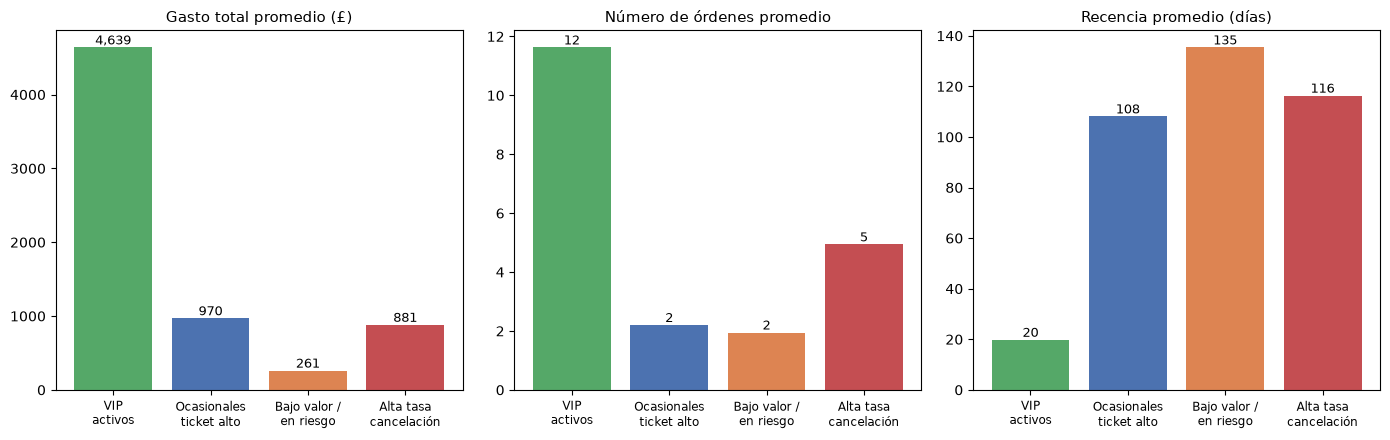

In [183]:
nombres_cluster = {0: 'Ocasionales\nticket alto', 1: 'Bajo valor /\nen riesgo',
                    2: 'VIP\nactivos', 3: 'Alta tasa\ncancelación'}
orden = [2, 0, 1, 3]  # VIP primero, luego de mayor a menor valor
paleta = {0: '#4C72B0', 1: '#DD8452', 2: '#55A868', 3: '#C44E52'}

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
metricas = [('Monetary', 'Gasto total promedio (£)'),
            ('Frequency', 'Número de órdenes promedio'),
            ('Recency', 'Recencia promedio (días)')]

for ax, (col, label) in zip(axes, metricas):
    vals = [rfm_perfil[rfm_perfil['Cluster']==c][col].mean() for c in orden]
    nombres = [nombres_cluster[c] for c in orden]
    colores = [paleta[c] for c in orden]
    bars = ax.bar(nombres, vals, color=colores)
    ax.set_title(label, fontsize=11)
    ax.tick_params(axis='x', labelsize=8.5)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v, f'{v:,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

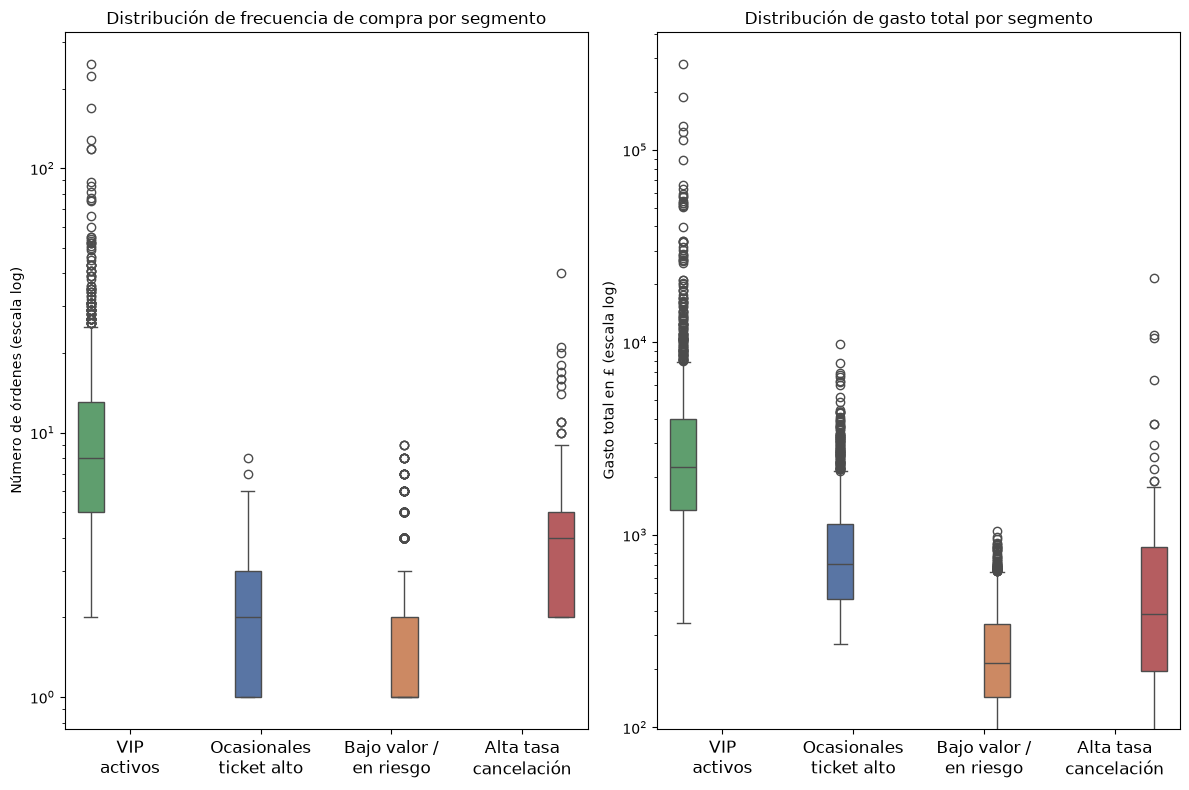

In [184]:
rfm_perfil['Nombre'] = rfm_perfil['Cluster'].map(nombres_cluster)
orden_nombres = [nombres_cluster[c] for c in orden]
rfm_perfil['Nombre_ord'] = pd.Categorical(rfm_perfil['Nombre'], categories=orden_nombres, ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 8))

sns.boxplot(x='Nombre_ord', y='Frequency', data=rfm_perfil, hue='Nombre_ord',
            palette=[paleta[c] for c in orden], legend=False, ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_xlabel(''); axes[0].set_ylabel('Número de órdenes (escala log)')
axes[0].set_title('Distribución de frecuencia de compra por segmento')
axes[0].tick_params(axis='x', labelsize=12)

sns.boxplot(x='Nombre_ord', y='Monetary', data=rfm_perfil, hue='Nombre_ord',
            palette=[paleta[c] for c in orden], legend=False, ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_xlabel(''); axes[1].set_ylabel('Gasto total en £ (escala log)')
axes[1].set_title('Distribución de gasto total por segmento')
axes[1].tick_params(axis='x', labelsize=12)

plt.tight_layout()
plt.show()

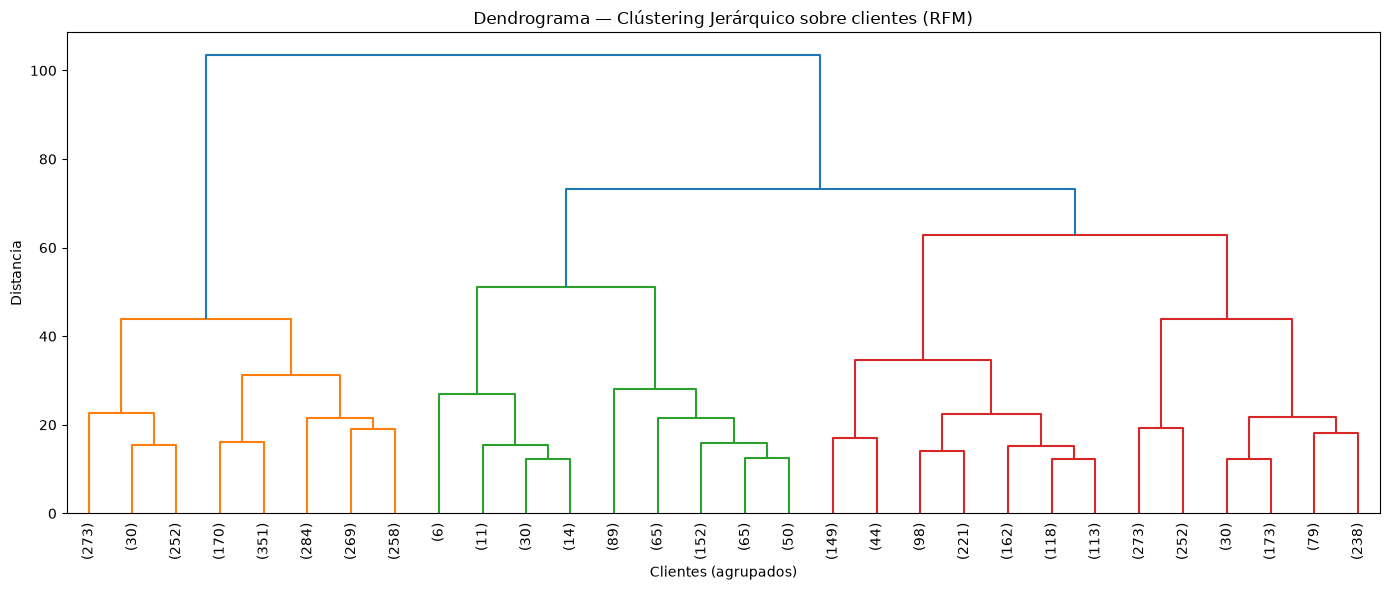

In [185]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# 1. Dendrograma (igual que en el Caso 10)
Z = linkage(scaled_normal, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90)
plt.title('Dendrograma — Clústering Jerárquico sobre clientes (RFM)')
plt.xlabel('Clientes (agrupados)')
plt.ylabel('Distancia')
plt.tight_layout()
plt.show()

In [186]:
# 2. Aplicar el clústering con el mismo k=4 del K-means, para comparar en igualdad de condiciones
agg = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels_agg = agg.fit_predict(scaled_normal)

print("Tamaños de clúster (Jerárquico):", np.bincount(labels_agg))
print(f"Silhouette (Jerárquico): {silhouette_score(scaled_normal, labels_agg):.3f}")

Tamaños de clúster (Jerárquico): [ 482 1887 1045  905]
Silhouette (Jerárquico): 0.210


In [187]:
# 3. Comparar qué tan de acuerdo están K-means y Jerárquico entre sí
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(kmeans_labels_rfm, labels_agg)
print(f"Índice de Rand ajustado (acuerdo entre K-means y Jerárquico): {ari:.3f}")

Índice de Rand ajustado (acuerdo entre K-means y Jerárquico): 0.386


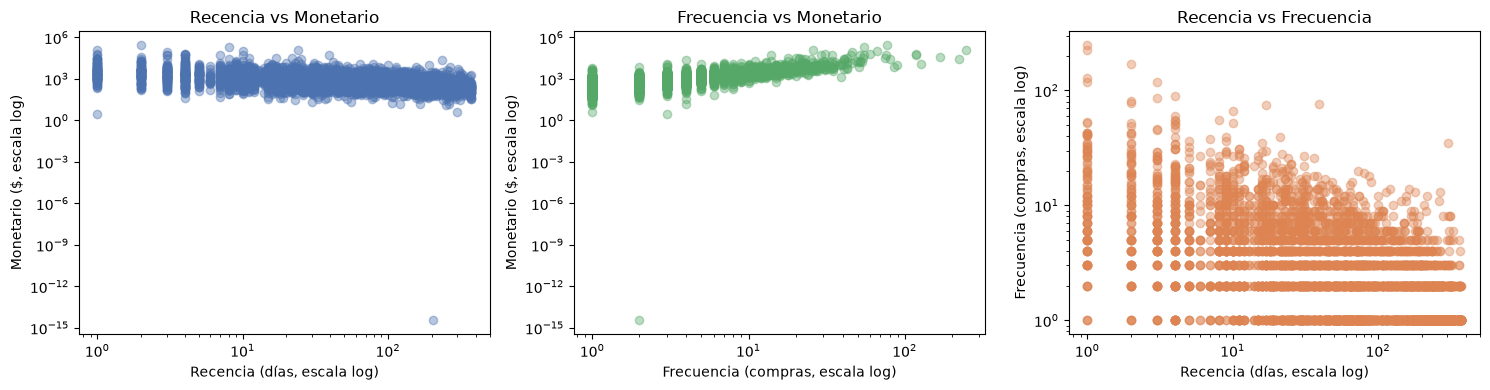

In [189]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(rfm_perfil['Recency'], rfm_perfil['Monetary'], alpha=0.4, color='#4C72B0')
axes[0].set_xscale('log'); axes[0].set_yscale('log')
axes[0].set_xlabel('Recencia (días, escala log)'); axes[0].set_ylabel('Monetario ($, escala log)')
axes[0].set_title('Recencia vs Monetario')

axes[1].scatter(rfm_perfil['Frequency'], rfm_perfil['Monetary'], alpha=0.4, color='#55A868')
axes[1].set_xscale('log'); axes[1].set_yscale('log')
axes[1].set_xlabel('Frecuencia (compras, escala log)'); axes[1].set_ylabel('Monetario ($, escala log)')
axes[1].set_title('Frecuencia vs Monetario')

axes[2].scatter(rfm_perfil['Recency'], rfm_perfil['Frequency'], alpha=0.4, color='#DD8452')
axes[2].set_xscale('log'); axes[2].set_yscale('log')
axes[2].set_xlabel('Recencia (días, escala log)'); axes[2].set_ylabel('Frecuencia (compras, escala log)')
axes[2].set_title('Recencia vs Frecuencia')

plt.tight_layout()
plt.show()

100%|██████████| 9/9 [00:03<00:00,  2.79it/s]


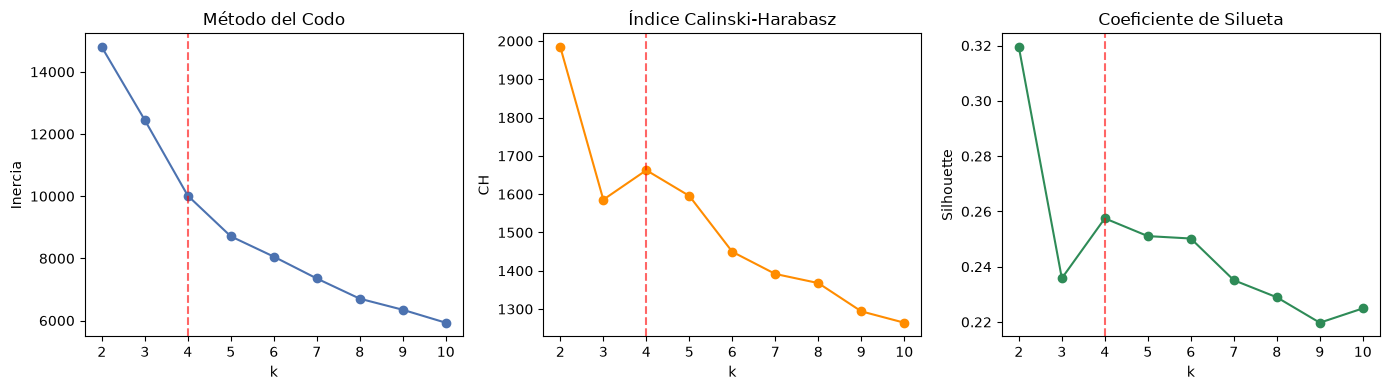

Silhouette en k=4: 0.257
Calinski-Harabasz en k=4: 1662.6


In [190]:
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score, silhouette_score
from tqdm import tqdm

inertia = []
CH_scores = []
silhouette_scores = []

for k in tqdm(range(2, 11)):
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels_tmp = km.fit_predict(scaled_normal)
    inertia.append(km.inertia_)
    CH_scores.append(calinski_harabasz_score(scaled_normal, labels_tmp))
    silhouette_scores.append(silhouette_score(scaled_normal, labels_tmp))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(range(2, 11), inertia, marker='o', color='#4C72B0')
axes[0].axvline(4, color='red', linestyle='--', alpha=0.6)
axes[0].set_title('Método del Codo')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inercia')

axes[1].plot(range(2, 11), CH_scores, marker='o', color='darkorange')
axes[1].axvline(4, color='red', linestyle='--', alpha=0.6)
axes[1].set_title('Índice Calinski-Harabasz')
axes[1].set_xlabel('k')
axes[1].set_ylabel('CH')

axes[2].plot(range(2, 11), silhouette_scores, marker='o', color='seagreen')
axes[2].axvline(4, color='red', linestyle='--', alpha=0.6)
axes[2].set_title('Coeficiente de Silueta')
axes[2].set_xlabel('k')
axes[2].set_ylabel('Silhouette')

plt.tight_layout()
plt.show()

print(f"Silhouette en k=4: {silhouette_scores[2]:.3f}")
print(f"Calinski-Harabasz en k=4: {CH_scores[2]:.1f}")